In [ ]:
import numpy as np
import rasterio
from rasterio.transform import rowcol
import rasterio.windows
import os, json
from huggingface_hub import snapshot_download

dataset_path = snapshot_download(
    repo_id="inessal/CropMappingSentinel2",
    repo_type="dataset"
)

# ================================================================
# 1. BAND DEFINITIONS
#
# New GeoTIFF layout (113 bands per file):
#   [0]      elevation      (m, SRTM)
#   [1]      landforms      (categorical)
#   [2]      soil_ph        (pH × 10  → ÷10 in Python)
#   [3]      soil_oc        (OC × 5   → ÷5  in Python)
#   [4]      soil_texture   (categorical)
#   [5–40]   temp_t00…t35   (K        → −273.15 in Python)
#   [41–76]  precip_t00…t35 (m        → ×1000   in Python)
#   [77–112] wind_t00…t35   (m/s, raw)
#
# Final output shape per sample: (N, 36, 8)
#   axis-2 layout per timestep:
#   [0] elevation  [1] landforms  [2] soil_ph  [3] soil_oc
#   [4] soil_texture  [5] temp  [6] precip  [7] wind
#   Static bands (0–4) are REPEATED across all 36 time steps.
# ================================================================

N_STATIC  = 5    # tif bands 0–4
N_STEPS   = 36
N_BANDS   = 8    # bands per timestep in the output array

# Slice indices within the 113-band flat read
STATIC_SLICE  = slice(0, 5)      # bands 0–4
TEMP_SLICE    = slice(5, 41)     # bands 5–40
PRECIP_SLICE  = slice(41, 77)    # bands 41–76
WIND_SLICE    = slice(77, 113)   # bands 77–112

N_TIF_BANDS   = 113

COV_BANDS = [
    'elevation',    # 0: continuous, m
    'landforms',    # 1: categorical (embedding)
    'soil_ph',      # 2: continuous, pH×10  → ÷10
    'soil_oc',      # 3: continuous, OC×5   → ÷5
    'soil_texture', # 4: categorical (embedding)
    'temp',         # 5: continuous, K      → −273.15
    'precip',       # 6: continuous, m      → ×1000
    'wind',         # 7: continuous, m/s
]

IDX             = {name: i for i, name in enumerate(COV_BANDS)}
CATEGORICAL_IDX = [IDX['landforms'], IDX['soil_texture']]  # [1, 4]
CONTINUOUS_IDX  = [IDX['elevation'], IDX['soil_ph'],
                   IDX['soil_oc'],   IDX['temp'],
                   IDX['precip'],    IDX['wind']]           # [0,2,3,5,6,7]

# ================================================================
# 2. LOAD COORDINATES + LABELS
# ================================================================
coords   = np.load(os.path.join(dataset_path, 'Arkansas_coords.npy'))
y_ark    = np.load(os.path.join(dataset_path, 'Arkansas_y.npy'))
mask_ark = np.load(os.path.join(dataset_path, 'Arkansas_mask.npy'))

cal_coords = np.load(os.path.join(dataset_path, 'California_coords.npy'))
y_cal      = np.load(os.path.join(dataset_path, 'California_y.npy'))
mask_cal   = np.load(os.path.join(dataset_path, 'California_mask.npy'))

# ================================================================
# 3. EXTRACTION  →  output shape: (N, 36, 8)
# ================================================================
def extract_temporal(coords, tif_path, desc=''):
    """
    Read a 113-band GeoTIFF and extract per-point values.

    Returns
    -------
    out : np.ndarray, shape (N, 36, 8), float32
        axis-0  : sample
        axis-1  : timestep (t00 … t35)
        axis-2  : band [elev, landforms, soil_ph, soil_oc,
                        soil_texture, temp, precip, wind]
        Static bands (0–4) are identical across all 36 timesteps.
    """
    src = rasterio.open(tif_path)
    N   = len(coords)

    assert src.count == N_TIF_BANDS, (
        f"{tif_path}: expected {N_TIF_BANDS} bands, got {src.count}"
    )

    out = np.full((N, N_STEPS, N_BANDS), np.nan, dtype=np.float32)
    oob = 0

    print(f"\nExtracting {desc} ({N} pts, {src.count} bands)")

    for i, (lon, lat) in enumerate(coords):
        try:
            r, c = rowcol(src.transform, lon, lat)
            if 0 <= r < src.height and 0 <= c < src.width:
                win  = rasterio.windows.Window(c, r, 1, 1)
                flat = src.read(window=win).reshape(-1).astype(np.float32)
                # flat shape: (113,)

                # ── Static bands → repeated across 36 timesteps ──
                static = flat[STATIC_SLICE]               # (5,)
                out[i, :, 0:5] = static[np.newaxis, :]   # broadcast (1,5)→(36,5)

                # ── Climate bands → one value per timestep ────────
                out[i, :, 5] = flat[TEMP_SLICE]           # (36,)
                out[i, :, 6] = flat[PRECIP_SLICE]         # (36,)
                out[i, :, 7] = flat[WIND_SLICE]           # (36,)
            else:
                oob += 1
        except Exception:
            oob += 1

        if (i + 1) % 2000 == 0:
            print(f"  {i+1}/{N}  ({oob} oob)")

    src.close()
    print(f"  Done — {oob} out-of-bounds")
    return out  # (N, 36, 8)


# ── Arkansas — single tile ────────────────────────────────────────
ark_path  = os.path.join(dataset_path, 'Covariates_Arkansas2.tif')
X_raw_ark = extract_temporal(coords, ark_path, 'Arkansas')
print(f"Arkansas  raw shape: {X_raw_ark.shape}")   # expect (10000, 36, 8)

# ── California — two tiles, route each point to the right one ────
cal1_path = os.path.join(dataset_path, 'Covariates_California_Area1.2.tif')
cal2_path = os.path.join(dataset_path, 'Covariates_California_Area2.2.tif')

src1 = rasterio.open(cal1_path)
src2 = rasterio.open(cal2_path)
assert src1.count == N_TIF_BANDS and src2.count == N_TIF_BANDS, \
    "California tile band count mismatch"
b1, b2 = src1.bounds, src2.bounds

N_cal     = len(cal_coords)
X_raw_cal = np.full((N_cal, N_STEPS, N_BANDS), np.nan, dtype=np.float32)
oob       = 0

print(f"\nExtracting California ({N_cal} pts, 2 tiles)")

for i, (lon, lat) in enumerate(cal_coords):
    in1 = b1.left <= lon <= b1.right and b1.bottom <= lat <= b1.top
    in2 = b2.left <= lon <= b2.right and b2.bottom <= lat <= b2.top
    src = src1 if in1 else (src2 if in2 else None)

    if src is None:
        oob += 1
        continue
    try:
        r, c = rowcol(src.transform, lon, lat)
        if 0 <= r < src.height and 0 <= c < src.width:
            win  = rasterio.windows.Window(c, r, 1, 1)
            flat = src.read(window=win).reshape(-1).astype(np.float32)

            static = flat[STATIC_SLICE]
            X_raw_cal[i, :, 0:5] = static[np.newaxis, :]
            X_raw_cal[i, :, 5]   = flat[TEMP_SLICE]
            X_raw_cal[i, :, 6]   = flat[PRECIP_SLICE]
            X_raw_cal[i, :, 7]   = flat[WIND_SLICE]
        else:
            oob += 1
    except Exception:
        oob += 1

    if (i + 1) % 2000 == 0:
        print(f"  {i+1}/{N_cal}  ({oob} oob)")

src1.close()
src2.close()
print(f"  Done — {oob} out-of-bounds")
print(f"California raw shape: {X_raw_cal.shape}")  # expect (10000, 36, 8)

# ================================================================
# 4. UNIT CORRECTIONS  —  applied along axis-2 (band axis)
# Static bands: correction is the same value repeated → fine
# Climate bands: each of the 36 timesteps corrected identically
# ================================================================
def correct_units(X, name=''):
    """X: (N, 36, 8)"""
    X = X.copy()
    X[:, :, IDX['soil_ph']] /= 10.0
    X[:, :, IDX['soil_oc']] /= 5.0
    X[:, :, IDX['temp']]    -= 273.15
    X[:, :, IDX['precip']]  *= 1000.0

    # Verification — collapse time axis for range checks
    print(f"\nUnit corrections — {name}:")
    print(f"  elevation : {X[:,:,IDX['elevation']].min():.0f}–"
          f"{X[:,:,IDX['elevation']].max():.0f} m")
    print(f"  soil_ph   : {X[:,:,IDX['soil_ph']].min():.2f}–"
          f"{X[:,:,IDX['soil_ph']].max():.2f} pH")
    print(f"  soil_oc   : {X[:,:,IDX['soil_oc']].min():.2f}–"
          f"{X[:,:,IDX['soil_oc']].max():.2f} g/kg")
    print(f"  temp      : {X[:,:,IDX['temp']].min():.1f}–"
          f"{X[:,:,IDX['temp']].max():.1f} °C")
    print(f"  precip    : {X[:,:,IDX['precip']].min():.1f}–"
          f"{X[:,:,IDX['precip']].max():.1f} mm  (per 10-day period)")
    print(f"  wind      : {X[:,:,IDX['wind']].min():.2f}–"
          f"{X[:,:,IDX['wind']].max():.2f} m/s")
    print(f"  landforms : "
          f"{np.unique(X[:,:,IDX['landforms']].astype(int)).tolist()}")
    print(f"  soil_tex  : "
          f"{np.unique(X[:,:,IDX['soil_texture']].astype(int)).tolist()}")
    return X

X_corr_ark = correct_units(X_raw_ark, 'Arkansas')
X_corr_cal = correct_units(X_raw_cal, 'California')

# ================================================================
# 5. NaN FILLING  —  operate on (N×36, 8) then reshape back
# ================================================================
def fill_nans(X, name=''):
    """X: (N, 36, 8)"""
    N, T, B = X.shape
    X_flat  = X.reshape(-1, B)   # (N×36, 8) — treat each (sample,t) as a row

    n_nan = np.isnan(X_flat).sum()
    if n_nan == 0:
        print(f"  {name}: no NaNs ✓")
        return X

    print(f"  {name}: {n_nan} NaNs → filling")
    X_flat = X_flat.copy()

    for col in range(B):
        nan_mask = np.isnan(X_flat[:, col])
        if not nan_mask.any():
            continue
        if col in CATEGORICAL_IDX:
            vals, counts = np.unique(
                X_flat[~nan_mask, col].astype(int), return_counts=True)
            fill_val = float(vals[np.argmax(counts)])
            print(f"    col {col} ({COV_BANDS[col]}): mode = {fill_val}")
        else:
            fill_val = float(np.nanmean(X_flat[:, col]))
            print(f"    col {col} ({COV_BANDS[col]}): mean = {fill_val:.4f}")
        X_flat[nan_mask, col] = fill_val

    return X_flat.reshape(N, T, B)

X_corr_ark = fill_nans(X_corr_ark, 'Arkansas')
X_corr_cal = fill_nans(X_corr_cal, 'California')


def build_category_map(X_ark, X_cal, col):
    """X: (N, 36, 8) — samples from t=0 slice"""
    all_vals = np.union1d(
        np.unique(X_ark[:, 0, col].astype(int)),
        np.unique(X_cal[:, 0, col].astype(int))
    )
    return {int(v): i for i, v in enumerate(sorted(all_vals))}

lf_map = build_category_map(X_corr_ark, X_corr_cal, IDX['landforms'])
tx_map = build_category_map(X_corr_ark, X_corr_cal, IDX['soil_texture'])

print(f"\nLandform  classes: {len(lf_map)}  "
      f"→ embedding dim suggestion: {min(50, (len(lf_map)+1)//2)}")
print(f"Texture   classes: {len(tx_map)}  "
      f"→ embedding dim suggestion: {min(50, (len(tx_map)+1)//2)}")
print(f"  lf_map: {lf_map}")
print(f"  tx_map: {tx_map}")

def apply_category_maps(X, lf_map, tx_map, name=''):
    """X: (N, 36, 8) — remap both categorical cols across all timesteps"""
    X = X.copy()
    lf_col = IDX['landforms']
    tx_col = IDX['soil_texture']
    # Vectorised remap using numpy (avoids slow Python loop over N×36 rows)
    lf_vals = X[:, :, lf_col].astype(int)
    tx_vals = X[:, :, tx_col].astype(int)
    lf_remapped = np.vectorize(lambda v: lf_map.get(v, 0))(lf_vals)
    tx_remapped = np.vectorize(lambda v: tx_map.get(v, 0))(tx_vals)
    X[:, :, lf_col] = lf_remapped.astype(np.float32)
    X[:, :, tx_col] = tx_remapped.astype(np.float32)
    print(f"  {name} landforms remapped: "
          f"{np.unique(lf_remapped).tolist()}")
    print(f"  {name} texture   remapped: "
          f"{np.unique(tx_remapped).tolist()}")
    return X

print("\nRemapping categoricals to 0-based indices:")
X_corr_ark = apply_category_maps(X_corr_ark, lf_map, tx_map, 'Arkansas')
X_corr_cal = apply_category_maps(X_corr_cal, lf_map, tx_map, 'California')

# ================================================================
# 7. NORMALIZE CONTINUOUS BANDS — PER STATE
#
# Stats computed over ALL (N × 36) values for each continuous band
# so that temporal variation within a band is included in the scale.
# Categorical bands (1, 4) are skipped — they stay as integers.
# ================================================================
def normalize_state(X, name=''):
    """
    X    : (N, 36, 8)
    Returns
    -------
    X_norm : (N, 36, 8) float32
    stats  : dict {band_name: {mean, std}}
    """
    X     = X.copy().astype(np.float32)
    stats = {}

    print(f"\nNormalizing {name} (fit on own data, all timesteps):")
    for col in CONTINUOUS_IDX:
        band = COV_BANDS[col]
        vals = X[:, :, col]          # (N, 36)
        mu   = float(vals.mean())
        std  = float(vals.std())
        std  = std if std > 1e-6 else 1.0
        X[:, :, col] = (vals - mu) / std
        stats[band]  = {'mean': mu, 'std': std}
        print(f"  [{col}] {band:12s}: mu={mu:.4f}  std={std:.4f}"
              f"  → range [{X[:,:,col].min():.2f}, {X[:,:,col].max():.2f}]")

    return X, stats

X_norm_ark, stats_ark = normalize_state(X_corr_ark, 'Arkansas')
X_norm_cal, stats_cal = normalize_state(X_corr_cal, 'California')

# ================================================================
# 8. VERIFICATION
# ================================================================
print("\n" + "="*60)
print("VERIFICATION")
print("="*60)

for state, X_raw, X_norm in [
    ('Arkansas',   X_corr_ark, X_norm_ark),
    ('California', X_corr_cal, X_norm_cal),
]:
    print(f"\n{state}  shape={X_raw.shape}  — raw (human units, t=0 slice):")
    for b, name in enumerate(COV_BANDS):
        v = X_raw[:, 0, b]   # t=0; static identical across t, climate representative
        print(f"  [{b}] {name:14s}: "
              f"min={v.min():8.2f}  max={v.max():8.2f}  mean={v.mean():8.2f}")

    print(f"\n{state} — temporal range of climate bands (all 36 steps):")
    for col in [IDX['temp'], IDX['precip'], IDX['wind']]:
        v = X_raw[:, :, col]
        print(f"  [{col}] {COV_BANDS[col]:8s}: "
              f"min={v.min():.2f}  max={v.max():.2f}  "
              f"mean={v.mean():.2f}  std={v.std():.2f}")

    print(f"\n{state} — normalized continuous (expect ~N(0,1)):")
    for col in CONTINUOUS_IDX:
        v = X_norm[:, :, col]
        print(f"  [{col}] {COV_BANDS[col]:12s}: "
              f"mean={v.mean():+.3f}  std={v.std():.3f}"
              f"  range=[{v.min():.2f}, {v.max():.2f}]")

    print(f"\n{state} — categorical (0-based integers):")
    for col in CATEGORICAL_IDX:
        uniq = np.unique(X_norm[:, 0, col].astype(int)).tolist()
        print(f"  [{col}] {COV_BANDS[col]:14s}: {len(uniq)} classes → {uniq}")

# ================================================================
# 9. SAVE
# ================================================================
print("\n" + "="*60)
print("SAVING")
print("="*60)

# Training-ready: (N, 36, 8) — normalized continuous, integer categoricals
np.save(os.path.join(dataset_path, 'Arkansas_X_cov2.npy'),
        X_norm_ark.astype(np.float32))
np.save(os.path.join(dataset_path, 'California_X_cov2.npy'),
        X_norm_cal.astype(np.float32))

# Human-readable: (N, 36, 8) — corrected units, remapped categoricals
np.save(os.path.join(dataset_path, 'Arkansas_X_cov_raw2.npy'),
        X_corr_ark.astype(np.float32))
np.save(os.path.join(dataset_path, 'California_X_cov_raw2.npy'),
        X_corr_cal.astype(np.float32))

# Normalization stats
with open(os.path.join(dataset_path, 'cov_stats_arkansas2.json'), 'w') as f:
    json.dump(stats_ark, f, indent=2)
with open(os.path.join(dataset_path, 'cov_stats_california2.json'), 'w') as f:
    json.dump(stats_cal, f, indent=2)

# Shared category maps
with open(os.path.join(dataset_path, 'cov_category_maps2.json'), 'w') as f:
    json.dump({'landforms': lf_map, 'soil_texture': tx_map}, f, indent=2)

# Metadata
meta = {
    'cov_bands':          COV_BANDS,
    'output_shape':       '(N, 36, 8)',
    'continuous_idx':     CONTINUOUS_IDX,
    'categorical_idx':    CATEGORICAL_IDX,
    'n_landform_classes': len(lf_map),
    'n_texture_classes':  len(tx_map),
    'tif_band_layout': {
        'static':  '0–4   (elevation, landforms, soil_ph, soil_oc, soil_texture)',
        'temp':    '5–40  (temp_t00…t35, raw K)',
        'precip':  '41–76 (precip_t00…t35, raw m)',
        'wind':    '77–112(wind_t00…t35, m/s)',
    }
}
with open(os.path.join(dataset_path, 'cov_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print(f"\n✅  Saved:")
print(f"  Arkansas_X_cov.npy        {X_norm_ark.shape}  ← training")
print(f"  California_X_cov.npy      {X_norm_cal.shape}  ← training")
print(f"  Arkansas_X_cov_raw.npy    {X_corr_ark.shape}  ← EDA")
print(f"  California_X_cov_raw.npy  {X_corr_cal.shape}  ← EDA")
print(f"\nBand layout per timestep (axis-2, 8 bands):")
for i, name in enumerate(COV_BANDS):
    kind = ('categorical (0-based int, for embedding)'
            if i in CATEGORICAL_IDX else 'continuous (normalized per state)')
    static = '← static, repeated' if i < 5 else '← varies per timestep'
    print(f"  [{i}] {name:14s}  {kind}  {static}")
print(f"\nAt training time:")
print(f"  X_cov shape : (N, 36, 8)")
print(f"  continuous  : X_cov[:, :, {CONTINUOUS_IDX}]")
print(f"  landforms   : X_cov[:, 0, 1].long()  "
      f"→ Embedding({len(lf_map)}, emb_dim)")
print(f"  texture     : X_cov[:, 0, 4].long()  "
      f"→ Embedding({len(tx_map)}, emb_dim)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 45 files:   0%|          | 0/45 [00:00<?, ?it/s]


Extracting Arkansas (10000 pts, 113 bands)
  2000/10000  (0 oob)
  4000/10000  (0 oob)
  6000/10000  (0 oob)
  8000/10000  (0 oob)
  10000/10000  (0 oob)
  Done — 0 out-of-bounds
Arkansas  raw shape: (10000, 36, 8)

Extracting California (10000 pts, 2 tiles)
  2000/10000  (0 oob)
  4000/10000  (0 oob)
  6000/10000  (0 oob)
  8000/10000  (0 oob)
  10000/10000  (0 oob)
  Done — 0 out-of-bounds
California raw shape: (10000, 36, 8)

Unit corrections — Arkansas:
  elevation : 46–80 m
  soil_ph   : 0.00–7.80 pH
  soil_oc   : 0.00–4.80 g/kg
  temp      : -5.0–29.6 °C
  precip    : 2.0–151.0 mm  (per 10-day period)
  wind      : 0.79–3.61 m/s
  landforms : [12, 21, 22, 24, 31, 32, 34, 41, 42]
  soil_tex  : [0, 1, 2, 4, 5, 7, 8]

Unit corrections — California:
  elevation : -3–135 m
  soil_ph   : 0.00–8.20 pH
  soil_oc   : 0.00–3.40 g/kg
  temp      : 6.1–34.4 °C
  precip    : 0.0–153.8 mm  (per 10-day period)
  wind      : 0.42–3.50 m/s
  landforms : [21, 22, 24, 31, 32, 34, 41, 42]
  soil_te

In [ ]:
import os

for root, dirs, files in os.walk("/"):
    for name in files:
        if "Arkansas_X_cov2.npy" in name:
            print(os.path.join(root, name))

/root/.cache/huggingface/hub/datasets--inessal--CropMappingSentinel2/snapshots/c23f9172bf04ae27dc1d4e8fc1bcb68af2958954/Arkansas_X_cov2.npy


In [ ]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
from huggingface_hub import upload_file

repo_id = "inessal/CropMappingSentinel2"

files = [
    "Arkansas_X_cov2.npy",
    "California_X_cov2.npy",
    "Arkansas_X_cov_raw2.npy",
    "California_X_cov_raw2.npy",
    "cov_stats_arkansas2.json",
    "cov_stats_california2.json",
    "cov_category_maps2.json"
]

base_path = "/root/.cache/huggingface/hub/datasets--inessal--CropMappingSentinel2/snapshots/c23f9172bf04ae27dc1d4e8fc1bcb68af2958954/"

for f in files:
    upload_file(
        path_or_fileobj=base_path + f,
        path_in_repo=f,
        repo_id=repo_id,
        repo_type="dataset"
    )

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...58954/Arkansas_X_cov2.npy:  72%|#######1  | 8.28MB / 11.5MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

New Data Upload               : |          |  0.00B /  0.00B            

  ...4/Arkansas_X_cov_raw2.npy:  92%|#########2| 10.6MB / 11.5MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...California_X_cov_raw2.npy:  18%|#7        | 2.03MB / 11.5MB            

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

def apply_pca_projection(X_cov_ark, X_cov_cal, n_components=10):
    if X_cov_ark.shape[1] == 0:
        return X_cov_ark, X_cov_cal

    pca = PCA(n_components=n_components)
    pca.fit(X_cov_ark)

    X_ark_proj = pca.transform(X_cov_ark).astype(np.float32)
    X_cal_proj = pca.transform(X_cov_cal).astype(np.float32)

    print(f"  PCA: {X_cov_ark.shape[1]} → {n_components} dims")
    print(f"  Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

    return X_ark_proj, X_cal_proj

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA
from huggingface_hub import snapshot_download
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ===============================
# DATASET
# ===============================
class CropDataset(Dataset):
    def __init__(self, X, mask, y, label_map):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.float32)
        self.y = torch.tensor(
            [label_map[int(yi)] for yi in y],
            dtype=torch.long
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx], self.y[idx]


# ===============================
# DATA LOADING
# ===============================
dataset_path = snapshot_download(
    repo_id="inessal/CropMappingSentinel2",
    repo_type="dataset"
)

X_ark = (np.load(os.path.join(dataset_path, 'Arkansas_X.npy')) / 10000.0).reshape(-1, 36, 10)
mask_ark = np.load(os.path.join(dataset_path, 'Arkansas_mask.npy'))
y_ark = np.load(os.path.join(dataset_path, 'Arkansas_y.npy'))

X_cal = (np.load(os.path.join(dataset_path, 'California_X.npy')) / 10000.0).reshape(-1, 36, 10)
mask_cal = np.load(os.path.join(dataset_path, 'California_mask.npy'))
y_cal = np.load(os.path.join(dataset_path, 'California_y.npy'))

ark_label_map = {1:0, 2:1, 3:2, 5:3, 99:4}
cal_label_map = {69:0, 3:1, 36:2, 75:3, 204:4, 99:5}

ark_class_names = ['Corn','Cotton','Rice','Soybeans','Others']
cal_class_names = ['Grapes','Rice','Alfalfa','Almonds','Pistachios','Others']


FEATURE_GROUPS = {
    None: None,
    'climate': [5, 6, 7],
    'soil': [2, 3, 4],
    'topo': [0, 1],
    'all': list(range(8)),
}

# ===============================
# SPLIT FUNCTION
# ===============================
def make_split(X, mask, y, label_map, n_train=240, n_val=60, seed=42):
    rng = np.random.RandomState(seed)
    train_idx, val_idx, test_idx = [], [], []

    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        rng.shuffle(idx)

        train_idx.extend(idx[:n_train])
        val_idx.extend(idx[n_train:n_train + n_val])
        test_idx.extend(idx[n_train + n_val:])

    def make_ds(idx_list):
        return CropDataset(X[idx_list], mask[idx_list], y[idx_list], label_map)

    return (
        DataLoader(make_ds(train_idx), batch_size=32, shuffle=True),
        DataLoader(make_ds(val_idx), batch_size=32, shuffle=False),
        DataLoader(make_ds(test_idx), batch_size=32, shuffle=False),
    )


# ===============================
# PCA
# ===============================
def pca_project(cov_ark, cov_cal, n_components=10):
    if cov_ark is None:
        return None, None, 0

    n = min(n_components, cov_ark.shape[1])

    if cov_ark.shape[1] <= n:
        return cov_ark, cov_cal, cov_ark.shape[1]

    pca = PCA(n_components=n)
    pca.fit(cov_ark)

    ark_proj = pca.transform(cov_ark).astype(np.float32)
    cal_proj = pca.transform(cov_cal).astype(np.float32)

    print(f"  PCA {cov_ark.shape[1]}→{n} | variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

    return ark_proj, cal_proj, n


# ===============================
# LOADERS
# ===============================
def make_loaders(study):
    col_idx = FEATURE_GROUPS[study]

    if col_idx is None:
        X_ark_fused = X_ark
        X_cal_fused = X_cal
        n_cov = 0
    else:
        raw_ark = np.load(os.path.join(dataset_path, 'Arkansas_X_cov2.npy'))
        raw_cal = np.load(os.path.join(dataset_path, 'California_X_cov2.npy'))

        # (N, 36, n_sel) → mean over time → (N, n_sel)
        cov_ark = raw_ark[:, :, col_idx].mean(axis=1).astype(np.float32)
        cov_cal = raw_cal[:, :, col_idx].mean(axis=1).astype(np.float32)

        # PCA → (N, min(n_sel, 10))
        cov_ark, cov_cal, n_cov = pca_project(cov_ark, cov_cal, n_components=10)

        # Pad to exactly 10 dims if n_cov < 10
        if n_cov < 10:
            pad_ark = np.zeros((len(cov_ark), 10 - n_cov), dtype=np.float32)
            pad_cal = np.zeros((len(cov_cal), 10 - n_cov), dtype=np.float32)
            cov_ark = np.concatenate([cov_ark, pad_ark], axis=1)  # (N, 10)
            cov_cal = np.concatenate([cov_cal, pad_cal], axis=1)  # (N, 10)

        # Repeat across 36 timesteps → (N, 36, 10)
        cov_ark_3d = np.repeat(cov_ark[:, np.newaxis, :], 36, axis=1)
        cov_cal_3d = np.repeat(cov_cal[:, np.newaxis, :], 36, axis=1)

        # Additive fusion — pure math, no neural network
        X_ark_fused = X_ark + cov_ark_3d   # (N, 36, 10)
        X_cal_fused = X_cal + cov_cal_3d   # (N, 36, 10)

    print(f"\nConfig: S2 + {study}  |  n_cov={n_cov}")

    ark_loaders = make_split(X_ark_fused, mask_ark, y_ark, ark_label_map)
    cal_loaders = make_split(X_cal_fused, mask_cal, y_cal, cal_label_map)

    return ark_loaders, cal_loaders, n_cov


# ===============================
# MODEL BUILDER
# ===============================
def build_model(n_classes, mctnet_class):
    return mctnet_class(
        n_bands=10,
        n_stages=3,
        n_head=5,
        kernel_size=3,
        n_classes=n_classes
    ).to(device)


print("Setup complete ✓")
print("MCTNet architecture: n_bands=10, n_head=5")
print("Covariates injected via additive fusion before MCTNet input")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 45 files:   0%|          | 0/45 [00:00<?, ?it/s]

Setup complete ✓
MCTNet architecture: n_bands=10, n_head=5
Covariates injected via additive fusion before MCTNet input


the cell under this is to fix make_loaders

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA
from huggingface_hub import snapshot_download
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ===============================
# DATASET
# ===============================
class CropDataset(Dataset):
    def __init__(self, X, mask, y, label_map):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.float32)
        self.y = torch.tensor(
            [label_map[int(yi)] for yi in y],
            dtype=torch.long
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx], self.y[idx]


# ===============================
# DATA LOADING
# ===============================
dataset_path = snapshot_download(
    repo_id="inessal/CropMappingSentinel2",
    repo_type="dataset"
)

X_ark = (np.load(os.path.join(dataset_path, 'Arkansas_X.npy')) / 10000.0).reshape(-1, 36, 10)
mask_ark = np.load(os.path.join(dataset_path, 'Arkansas_mask.npy'))
y_ark = np.load(os.path.join(dataset_path, 'Arkansas_y.npy'))

X_cal = (np.load(os.path.join(dataset_path, 'California_X.npy')) / 10000.0).reshape(-1, 36, 10)
mask_cal = np.load(os.path.join(dataset_path, 'California_mask.npy'))
y_cal = np.load(os.path.join(dataset_path, 'California_y.npy'))

ark_label_map = {1:0, 2:1, 3:2, 5:3, 99:4}
cal_label_map = {69:0, 3:1, 36:2, 75:3, 204:4, 99:5}

ark_class_names = ['Corn','Cotton','Rice','Soybeans','Others']
cal_class_names = ['Grapes','Rice','Alfalfa','Almonds','Pistachios','Others']


FEATURE_GROUPS = {
    None: None,
    'climate': [5, 6, 7],
    'soil': [2, 3, 4],
    'topo': [0, 1],
    'all': list(range(8)),
}

# ===============================
# SPLIT FUNCTION
# ===============================
def make_split(X, mask, y, label_map, n_train=240, n_val=60, seed=42):
    rng = np.random.RandomState(seed)
    train_idx, val_idx, test_idx = [], [], []

    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        rng.shuffle(idx)

        train_idx.extend(idx[:n_train])
        val_idx.extend(idx[n_train:n_train + n_val])
        test_idx.extend(idx[n_train + n_val:])

    def make_ds(idx_list):
        return CropDataset(X[idx_list], mask[idx_list], y[idx_list], label_map)

    return (
        DataLoader(make_ds(train_idx), batch_size=32, shuffle=True),
        DataLoader(make_ds(val_idx), batch_size=32, shuffle=False),
        DataLoader(make_ds(test_idx), batch_size=32, shuffle=False),
    )


# ===============================
# PCA
# ===============================
def pca_project(cov_ark, cov_cal, n_components=10):
    if cov_ark is None:
        return None, None, 0

    n = min(n_components, cov_ark.shape[1])

    if cov_ark.shape[1] <= n:
        return cov_ark, cov_cal, cov_ark.shape[1]

    pca = PCA(n_components=n)
    pca.fit(cov_ark)

    ark_proj = pca.transform(cov_ark).astype(np.float32)
    cal_proj = pca.transform(cov_cal).astype(np.float32)

    print(f"  PCA {cov_ark.shape[1]}→{n} | variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

    return ark_proj, cal_proj, n


# ===============================
# LOADERS
# ===============================
def make_loaders(study):
    col_idx = FEATURE_GROUPS[study]

    if col_idx is None:
        X_ark_fused = X_ark
        X_cal_fused = X_cal
        n_cov = 0
    else:
        raw_ark = np.load(os.path.join(dataset_path, 'Arkansas_X_cov2.npy'))
        raw_cal = np.load(os.path.join(dataset_path, 'California_X_cov2.npy'))

        # (N, 36, k) — keep temporal dimension, do NOT average over time
        cov_ark = raw_ark[:, :, col_idx].astype(np.float32)  # (N, 36, k)
        cov_cal = raw_cal[:, :, col_idx].astype(np.float32)  # (N, 36, k)

        # PCA per timestep: reshape to (N*36, k) → PCA → (N*36, n) → reshape back
        k = cov_ark.shape[2]
        n_comp = min(k, 10)

        if k > n_comp:
            from sklearn.decomposition import PCA
            pca = PCA(n_components=n_comp)

            # Fit on Arkansas training data only
            ark_2d = cov_ark.reshape(-1, k)       # (N*36, k)
            cal_2d = cov_cal.reshape(-1, k)

            pca.fit(ark_2d)
            print(f"  PCA {k}→{n_comp} | variance: "
                  f"{pca.explained_variance_ratio_.sum()*100:.1f}%")

            cov_ark = pca.transform(ark_2d).reshape(
                len(cov_ark), 36, n_comp).astype(np.float32)
            cov_cal = pca.transform(cal_2d).reshape(
                len(cov_cal), 36, n_comp).astype(np.float32)
            n_cov = n_comp
        else:
            n_cov = k

        # Pad to exactly 10 if needed
        if n_cov < 10:
            pad_ark = np.zeros(
                (len(cov_ark), 36, 10 - n_cov), dtype=np.float32)
            pad_cal = np.zeros(
                (len(cov_cal), 36, 10 - n_cov), dtype=np.float32)
            cov_ark = np.concatenate([cov_ark, pad_ark], axis=-1)
            cov_cal = np.concatenate([cov_cal, pad_cal], axis=-1)
            n_cov = 10

        # Additive fusion — shapes match exactly
        X_ark_fused = X_ark + cov_ark   # (N, 36, 10) + (N, 36, 10)
        X_cal_fused = X_cal + cov_cal

    print(f"\nConfig: S2 + {study}  |  X_fused: {X_ark_fused.shape}")

    print(f"\nConfig: S2 + {study}  |  n_cov={n_cov}")

    ark_loaders = make_split(X_ark_fused, mask_ark, y_ark, ark_label_map)
    cal_loaders = make_split(X_cal_fused, mask_cal, y_cal, cal_label_map)

    return ark_loaders, cal_loaders, n_cov


# ===============================
# MODEL BUILDER
# ===============================
def build_model(n_classes, mctnet_class):
    return mctnet_class(
        n_bands=10,
        n_stages=3,
        n_head=5,
        kernel_size=3,
        n_classes=n_classes
    ).to(device)


print("Setup complete ✓")
print("MCTNet architecture: n_bands=10, n_head=5")
print("Covariates injected via additive fusion before MCTNet input")

Fetching 45 files:   0%|          | 0/45 [00:00<?, ?it/s]

Setup complete ✓
MCTNet architecture: n_bands=10, n_head=5
Covariates injected via additive fusion before MCTNet input


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import warnings
warnings.filterwarnings('ignore')


class ALPE(nn.Module):
    def __init__(self, d=10, T=36):
        super().__init__()
        pe = torch.zeros(T, d)
        pos = torch.arange(T).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() * (-np.log(10000) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:pe[:, 1::2].shape[1]])
        self.register_buffer('pe', pe)
        self.conv = nn.Conv1d(d, d, kernel_size=3, padding=1)
        self.eca = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(d, d, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x, mask):
        pe = self.pe.unsqueeze(0).expand(x.size(0), -1, -1)
        pe = pe * (1 - mask.unsqueeze(-1))
        pe = pe.transpose(1, 2)
        pe = self.conv(pe)
        scale = self.eca(pe)
        pe = pe * scale
        return pe.transpose(1, 2)


class CNNBlock(nn.Module):
    def __init__(self, d, k=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(d, d, k, padding=k//2),
            nn.BatchNorm1d(d),
            nn.Conv1d(d, d, k, padding=k//2),
            nn.BatchNorm1d(d)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        xt = x.transpose(1, 2)
        out = self.net(xt)
        return self.relu(out + xt).transpose(1, 2)


class CTFusion(nn.Module):
    def __init__(self, d, n_head, k=3, use_alpe=False):
        super().__init__()
        self.use_alpe = use_alpe
        if use_alpe:
            self.alpe = ALPE(d=d)  # ← must pass d=d, not ALPE()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d,
            nhead           = n_head,
            dim_feedforward = d * 8,
            batch_first     = True,
            dropout         = 0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.cnn  = CNNBlock(d, k)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

    def forward(self, x, mask=None):
        if self.use_alpe and mask is not None:
            pos = self.alpe(x, mask)
            xt  = x + pos
        else:
            xt = x
        t_out = self.transformer(xt)
        c_out = self.cnn(xt)
        fused = torch.cat([t_out, c_out], dim=-1)
        out   = self.pool(fused.transpose(1, 2))
        return out.transpose(1, 2)

class MCTNet(nn.Module):
    def __init__(self, n_bands=10, n_stages=3,
                 n_head=5, kernel_size=3, n_classes=5):
        super().__init__()
        self.stages = nn.ModuleList()
        in_d = n_bands
        for i in range(n_stages):
            self.stages.append(
                CTFusion(
                    d        = in_d,
                    n_head   = n_head,
                    k        = kernel_size,
                    use_alpe = (i == 0)
                )
            )
            in_d *= 2
        self.classifier = nn.Linear(in_d, n_classes)

    def forward(self, x, mask=None):
        for stage in self.stages:
            x = stage(x, mask)
        x = x.max(dim=1).values
        return self.classifier(x)


print("MCTNet defined")

MCTNet defined


In [ ]:
print("=== FUSION PIPELINE CHECK ===\n")

for study in ['climate', 'soil', 'topo', 'all']:
    col_idx = FEATURE_GROUPS[study]

    # Mean aggregate over time
    cov_ark = raw_ark[:, :, col_idx].mean(axis=1)
    cov_cal = raw_cal[:, :, col_idx].mean(axis=1)
    print(f"[{study}]")
    print(f"  after mean-agg : {cov_ark.shape}  ← expect (10000, {len(col_idx)})")

    # PCA
    cov_ark_p, cov_cal_p, n_cov = pca_project(cov_ark, cov_cal, n_components=10)
    print(f"  after PCA      : {cov_ark_p.shape}  ← expect (10000, {min(len(col_idx), 10)})")

    # Pad
    if n_cov < 10:
        pad = np.zeros((len(cov_ark_p), 10 - n_cov), dtype=np.float32)
        cov_ark_p = np.concatenate([cov_ark_p, pad], axis=1)
    print(f"  after padding  : {cov_ark_p.shape}  ← expect (10000, 10)")

    # Repeat and fuse
    cov_3d      = np.repeat(cov_ark_p[:, np.newaxis, :], 36, axis=1)
    X_fused     = X_ark + cov_3d
    print(f"  after repeat   : {cov_3d.shape}   ← expect (10000, 36, 10)")
    print(f"  X_fused        : {X_fused.shape}   ← expect (10000, 36, 10)")
    print(f"  NaNs in fused  : {np.isnan(X_fused).sum()}  ← expect 0")
    print()

print("=== LOADER + BATCH CHECK ===\n")
for study in ['climate', 'soil', 'topo', 'all']:
    ark_loaders, cal_loaders, n_cov = make_loaders(study)
    X_batch, mask_batch, y_batch = next(iter(ark_loaders[0]))
    print(f"[{study}]")
    print(f"  X_batch    : {tuple(X_batch.shape)}  ← expect (32, 36, 10)")
    print(f"  mask_batch : {tuple(mask_batch.shape)}  ← expect (32, 36)")
    print(f"  y_batch    : {tuple(y_batch.shape)}  ← expect (32,)")
    print()

=== FUSION PIPELINE CHECK ===

[climate]
  after mean-agg : (10000, 3)  ← expect (10000, 3)
  after PCA      : (10000, 3)  ← expect (10000, 3)
  after padding  : (10000, 10)  ← expect (10000, 10)
  after repeat   : (10000, 36, 10)   ← expect (10000, 36, 10)
  X_fused        : (10000, 36, 10)   ← expect (10000, 36, 10)
  NaNs in fused  : 0  ← expect 0

[soil]
  after mean-agg : (10000, 3)  ← expect (10000, 3)
  after PCA      : (10000, 3)  ← expect (10000, 3)
  after padding  : (10000, 10)  ← expect (10000, 10)
  after repeat   : (10000, 36, 10)   ← expect (10000, 36, 10)
  X_fused        : (10000, 36, 10)   ← expect (10000, 36, 10)
  NaNs in fused  : 0  ← expect 0

[topo]
  after mean-agg : (10000, 2)  ← expect (10000, 2)
  after PCA      : (10000, 2)  ← expect (10000, 2)
  after padding  : (10000, 10)  ← expect (10000, 10)
  after repeat   : (10000, 36, 10)   ← expect (10000, 36, 10)
  X_fused        : (10000, 36, 10)   ← expect (10000, 36, 10)
  NaNs in fused  : 0  ← expect 0

[all]


In [ ]:
import numpy as np
import os

raw_ark = np.load(os.path.join(dataset_path, 'Arkansas_X_cov2.npy'))
raw_cal = np.load(os.path.join(dataset_path, 'California_X_cov2.npy'))

print("=== FILE SHAPES ===")
print(f"X_ark:        {X_ark.shape}        ← expect (10000, 36, 10)")
print(f"X_cal:        {X_cal.shape}        ← expect (10000, 36, 10)")
print(f"mask_ark:     {mask_ark.shape}     ← expect (10000, 36)")
print(f"mask_cal:     {mask_cal.shape}     ← expect (10000, 36)")
print(f"y_ark:        {y_ark.shape}        ← expect (10000,)")
print(f"y_cal:        {y_cal.shape}        ← expect (10000,)")
print(f"cov2_ark:     {raw_ark.shape}      ← expect (10000, 36, 8)")
print(f"cov2_cal:     {raw_cal.shape}      ← expect (10000, 36, 8)")

=== FILE SHAPES ===
X_ark:        (10000, 36, 10)        ← expect (10000, 36, 10)
X_cal:        (10000, 36, 10)        ← expect (10000, 36, 10)
mask_ark:     (10000, 36)     ← expect (10000, 36)
mask_cal:     (10000, 36)     ← expect (10000, 36)
y_ark:        (10000,)        ← expect (10000,)
y_cal:        (10000,)        ← expect (10000,)
cov2_ark:     (10000, 36, 8)      ← expect (10000, 36, 8)
cov2_cal:     (10000, 36, 8)      ← expect (10000, 36, 8)


In [ ]:
# Options: 'climate' | 'soil' | 'topo' | 'all' | None (S2-only)
STUDY = 'topo'

ark_loaders, cal_loaders, n_cov = make_loaders(STUDY)
ark_train, ark_val, ark_test    = ark_loaders
cal_train, cal_val, cal_test    = cal_loaders

model_ark = build_model(n_classes=5, mctnet_class=MCTNet)
model_cal = build_model(n_classes=6, mctnet_class=MCTNet)

print(f"Model built for: S2 + {STUDY}")
print(f"MCTNet input: always (batch, 36, 10) ")


Config: S2 + topo  |  X_fused: (10000, 36, 10)

Config: S2 + topo  |  n_cov=10
Model built for: S2 + topo
MCTNet input: always (batch, 36, 10) 


In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
from sklearn.metrics import cohen_kappa_score, f1_score
import numpy as np
import matplotlib.pyplot as plt


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, mask_batch, y_batch in loader:
        X_batch    = X_batch.to(device)
        mask_batch = mask_batch.to(device)
        y_batch    = y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch, mask_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += outputs.argmax(dim=1).eq(y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, mask_batch, y_batch in loader:
            X_batch    = X_batch.to(device)
            mask_batch = mask_batch.to(device)
            y_batch    = y_batch.to(device)
            outputs = model(X_batch, mask_batch)
            loss    = criterion(outputs, y_batch)
            total_loss += loss.item() * len(y_batch)
            preds       = outputs.argmax(dim=1)
            correct    += preds.eq(y_batch).sum().item()
            total      += len(y_batch)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    oa    = correct / total
    kappa = cohen_kappa_score(all_labels, all_preds)
    f1    = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / total, oa, kappa, f1, all_preds, all_labels


def train_model(model, train_loader, val_loader,
                n_epochs=200, lr=0.001,
                weight_decay=1e-3,
                patience=20,
                device='cuda',
                state_name=''):

    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_kappa    = 0.0
    best_epoch        = 0
    best_weights      = None
    epochs_no_improve = 0

    history = {
        'train_loss': [], 'val_loss':  [],
        'train_oa':   [], 'val_oa':    [],
        'val_kappa':  [], 'val_f1':    []
    }

    print(f"\n{'='*70}")
    print(f"Training MCTNet on {state_name}")
    print(f"  lr={lr}, weight_decay={weight_decay}, patience={patience}")
    print(f"{'='*70}")
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train OA':>9} | "
          f"{'Val Loss':>9} | {'Val OA':>7} | {'Val Kappa':>9} | {'Val F1':>7}")
    print(f"{'-'*70}")

    for epoch in range(1, n_epochs + 1):
        train_loss, train_oa = train_one_epoch(
            model, train_loader, optimizer, criterion, device)
        val_loss, val_oa, val_kappa, val_f1, _, _ = evaluate(
            model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_oa'].append(train_oa)
        history['val_oa'].append(val_oa)
        history['val_kappa'].append(val_kappa)
        history['val_f1'].append(val_f1)

        if val_kappa > best_val_kappa:
            best_val_kappa    = val_kappa
            best_epoch        = epoch
            best_weights      = {k: v.cpu().clone()
                                 for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epoch % 10 == 0 or epoch == 1:
            marker = ' ← best' if epoch == best_epoch else ''
            print(f"{epoch:>6} | {train_loss:>10.4f} | {train_oa:>9.4f} | "
                  f"{val_loss:>9.4f} | {val_oa:>7.4f} | "
                  f"{val_kappa:>9.4f} | {val_f1:>7.4f}{marker}")

        if epochs_no_improve >= patience:
            print(f"\n⏹ Early stopping at epoch {epoch} "
                  f"(no improvement for {patience} epochs)")
            break

    print(f"\n✅ Best model at epoch {best_epoch} "
          f"with Val Kappa = {best_val_kappa:.4f}")
    model.load_state_dict({k: v.to(device)
                           for k, v in best_weights.items()})
    return model, history


def plot_history(history, state_name):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(history['train_loss'], label='Train', color='blue')
    axes[0].plot(history['val_loss'],   label='Val',   color='orange')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(history['train_oa'], label='Train', color='blue')
    axes[1].plot(history['val_oa'],   label='Val',   color='orange')
    axes[1].set_title('Overall Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[2].plot(history['val_kappa'], label='Kappa', color='green')
    axes[2].plot(history['val_f1'],    label='F1',    color='red')
    axes[2].set_title('Val Kappa & F1')
    axes[2].set_xlabel('Epoch')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    plt.suptitle(f'MCTNet Training — {state_name}', fontsize=13)
    plt.tight_layout()
    plt.show()


Training MCTNet on Arkansas — S2 + topo
  lr=0.001, weight_decay=0.005, patience=15
 Epoch | Train Loss |  Train OA |  Val Loss |  Val OA | Val Kappa |  Val F1
----------------------------------------------------------------------
     1 |     1.4370 |    0.3708 |    1.2560 |  0.5767 |    0.4708 |  0.5525 ← best
    10 |     0.2909 |    0.8992 |    0.3295 |  0.8867 |    0.8583 |  0.8886
    20 |     0.1484 |    0.9567 |    0.3058 |  0.9000 |    0.8750 |  0.9011
    30 |     0.0942 |    0.9800 |    0.1978 |  0.9300 |    0.9125 |  0.9302
    40 |     0.0743 |    0.9875 |    0.2364 |  0.9067 |    0.8833 |  0.9084

⏹ Early stopping at epoch 46 (no improvement for 15 epochs)

✅ Best model at epoch 31 with Val Kappa = 0.9292

FINAL TEST RESULTS — Arkansas (S2 + topo)
  OA:    0.9155
  Kappa: 0.8735
  F1:    0.8839


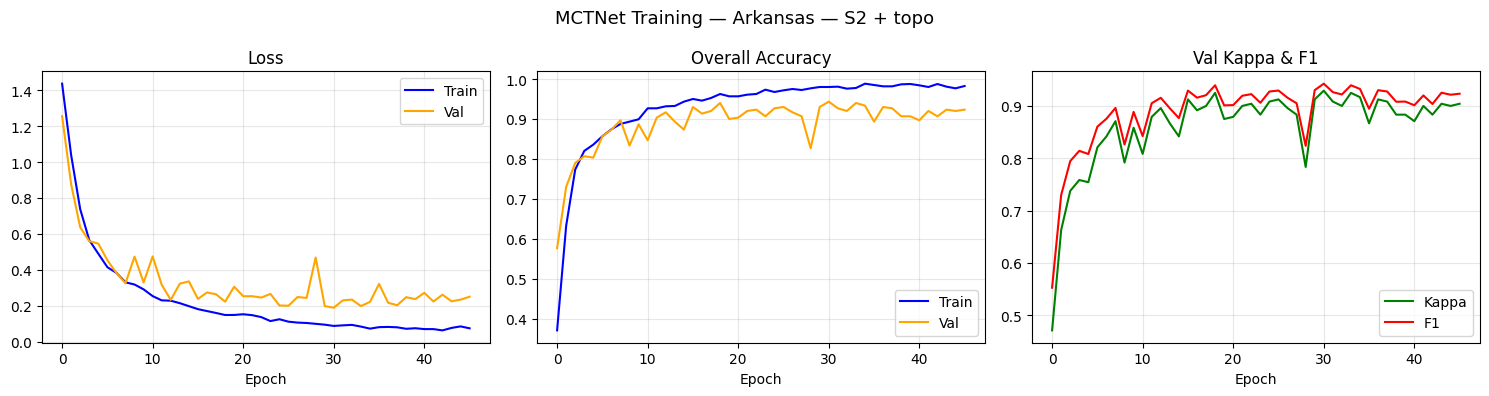

In [ ]:
# ── Arkansas ──────────────────────────────────────────────────────
model_ark, history_ark = train_model(
    model        = model_ark,
    train_loader = ark_train,
    val_loader   = ark_val,
    n_epochs     = 200,
    lr           = 0.001,
    weight_decay = 5e-3,
    patience     = 15,
    device       = device,
    state_name   = f'Arkansas — S2 + {STUDY}'
)

print("\n" + "="*60)
print(f"FINAL TEST RESULTS — Arkansas (S2 + {STUDY})")
print("="*60)
_, test_oa_ark, test_kappa_ark, test_f1_ark, preds_ark, labels_ark = evaluate(
    model_ark, ark_test, nn.CrossEntropyLoss(), device)
print(f"  OA:    {test_oa_ark:.4f}")
print(f"  Kappa: {test_kappa_ark:.4f}")
print(f"  F1:    {test_f1_ark:.4f}")
plot_history(history_ark, f'Arkansas — S2 + {STUDY}')


Training MCTNet on California — S2 + topo
  lr=0.001, weight_decay=0.005, patience=15
 Epoch | Train Loss |  Train OA |  Val Loss |  Val OA | Val Kappa |  Val F1
----------------------------------------------------------------------
     1 |     1.2657 |    0.4750 |    0.9879 |  0.6056 |    0.5267 |  0.5670 ← best
    10 |     0.4126 |    0.8646 |    0.5854 |  0.7833 |    0.7400 |  0.7722
    20 |     0.2987 |    0.8986 |    0.3673 |  0.8722 |    0.8467 |  0.8721
    30 |     0.2315 |    0.9278 |    0.3234 |  0.8833 |    0.8600 |  0.8823
    40 |     0.1827 |    0.9486 |    0.3282 |  0.8833 |    0.8600 |  0.8818

⏹ Early stopping at epoch 46 (no improvement for 15 epochs)

✅ Best model at epoch 31 with Val Kappa = 0.8800

FINAL TEST RESULTS — California (S2 + topo)
  OA:    0.8415
  Kappa: 0.7941
  F1:    0.8218


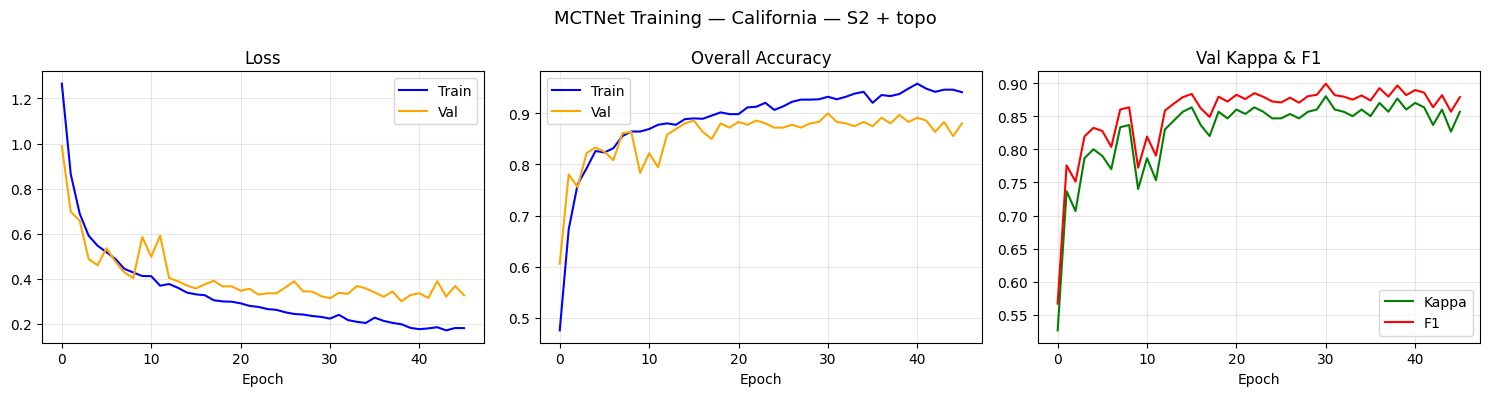

In [ ]:
# ── California ────────────────────────────────────────────────────
model_cal, history_cal = train_model(
    model        = model_cal,
    train_loader = cal_train,
    val_loader   = cal_val,
    n_epochs     = 200,
    lr           = 0.001,
    weight_decay = 5e-3,
    patience     = 15,
    device       = device,
    state_name   = f'California — S2 + {STUDY}'
)

print("\n" + "="*60)
print(f"FINAL TEST RESULTS — California (S2 + {STUDY})")
print("="*60)
_, test_oa_cal, test_kappa_cal, test_f1_cal, preds_cal, labels_cal = evaluate(
    model_cal, cal_test, nn.CrossEntropyLoss(), device)
print(f"  OA:    {test_oa_cal:.4f}")
print(f"  Kappa: {test_kappa_cal:.4f}")
print(f"  F1:    {test_f1_cal:.4f}")
plot_history(history_cal, f'California — S2 + {STUDY}')

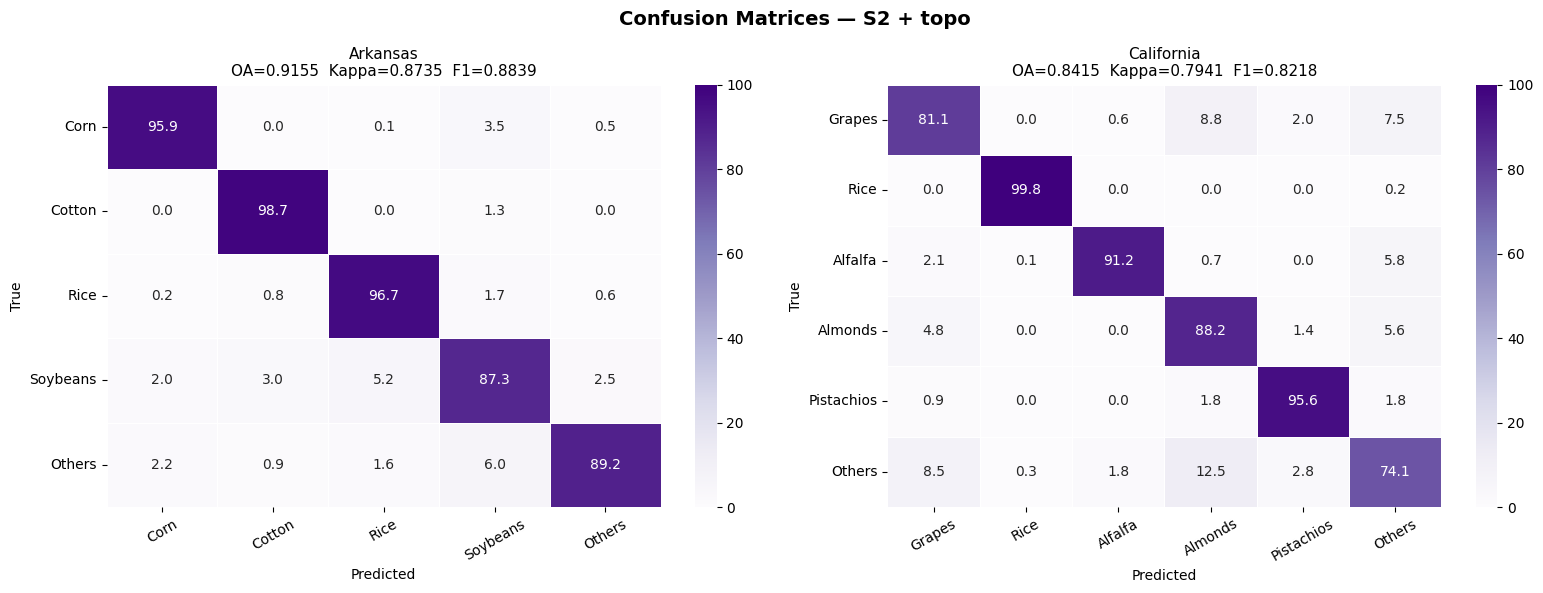


CLASSIFICATION REPORT — Arkansas (S2 + topo)
              precision    recall  f1-score   support

        Corn     0.9221    0.9591    0.9402      1222
      Cotton     0.7475    0.9870    0.8507       462
        Rice     0.8981    0.9670    0.9313      2123
    Soybeans     0.9735    0.8725    0.9202      4377
      Others     0.6878    0.8924    0.7769       316

    accuracy                         0.9155      8500
   macro avg     0.8458    0.9356    0.8839      8500
weighted avg     0.9244    0.9155    0.9168      8500


CLASSIFICATION REPORT — California (S2 + topo)
              precision    recall  f1-score   support

      Grapes     0.8191    0.8107    0.8149      1754
        Rice     0.9943    0.9977    0.9960      1737
     Alfalfa     0.9004    0.9125    0.9064       674
     Almonds     0.4281    0.8820    0.5765       483
  Pistachios     0.7127    0.9559    0.8166       340
      Others     0.9196    0.7407    0.8205      3212

    accuracy                         

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def plot_confusion_matrices(preds_ark, labels_ark,
                             preds_cal, labels_cal,
                             study_name):
    cm_ark = confusion_matrix(labels_ark, preds_ark)
    cm_cal = confusion_matrix(labels_cal, preds_cal)

    cm_ark_pct = cm_ark.astype(float) / cm_ark.sum(axis=1, keepdims=True) * 100
    cm_cal_pct = cm_cal.astype(float) / cm_cal.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Confusion Matrices — S2 + {study_name}',
                 fontsize=14, fontweight='bold')

    # Arkansas
    sns.heatmap(cm_ark_pct, ax=axes[0],
                annot=True, fmt='.1f', cmap='Purples',
                xticklabels=ark_class_names,
                yticklabels=ark_class_names,
                vmin=0, vmax=100,
                linewidths=0.5, linecolor='white')
    axes[0].set_title(f'Arkansas\nOA={test_oa_ark:.4f}  '
                      f'Kappa={test_kappa_ark:.4f}  '
                      f'F1={test_f1_ark:.4f}',
                      fontsize=11)
    axes[0].set_xlabel('Predicted', fontsize=10)
    axes[0].set_ylabel('True', fontsize=10)
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].tick_params(axis='y', rotation=0)

    # California
    sns.heatmap(cm_cal_pct, ax=axes[1],
                annot=True, fmt='.1f', cmap='Purples',
                xticklabels=cal_class_names,
                yticklabels=cal_class_names,
                vmin=0, vmax=100,
                linewidths=0.5, linecolor='white')
    axes[1].set_title(f'California\nOA={test_oa_cal:.4f}  '
                      f'Kappa={test_kappa_cal:.4f}  '
                      f'F1={test_f1_cal:.4f}',
                      fontsize=11)
    axes[1].set_xlabel('Predicted', fontsize=10)
    axes[1].set_ylabel('True', fontsize=10)
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.show()

    # ── Classification reports
    print(f"\n{'='*60}")
    print(f"CLASSIFICATION REPORT — Arkansas (S2 + {study_name})")
    print(f"{'='*60}")
    print(classification_report(
        labels_ark, preds_ark,
        target_names=ark_class_names,
        digits=4,
        zero_division=0
    ))

    print(f"\n{'='*60}")
    print(f"CLASSIFICATION REPORT — California (S2 + {study_name})")
    print(f"{'='*60}")
    print(classification_report(
        labels_cal, preds_cal,
        target_names=cal_class_names,
        digits=4,
        zero_division=0
    ))


plot_confusion_matrices(
    preds_ark, labels_ark,
    preds_cal, labels_cal,
    study_name=str(STUDY)
)

TRY part 3

In [ ]:
import torch
import torch.nn as nn
import numpy as np


class ALPE(nn.Module):
    def __init__(self, d=10, T=36):
        super().__init__()
        # Pre-compute PE for max length T
        pe  = torch.zeros(T, d)
        pos = torch.arange(T).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d, 2).float() * (-np.log(10000) / d)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:pe[:, 1::2].shape[1]])
        self.register_buffer('pe', pe)
        self.conv = nn.Conv1d(d, d, kernel_size=3, padding=1)
        self.eca  = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(d, d, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x, mask):
        T_current = x.shape[1]                                    
        pe = self.pe[:T_current].unsqueeze(0).expand(             
            x.size(0), -1, -1
        )
        if mask is not None:
            pe = pe * (1 - mask.unsqueeze(-1))
        pe    = pe.transpose(1, 2)
        pe    = self.conv(pe)
        scale = self.eca(pe)
        pe    = pe * scale
        return pe.transpose(1, 2)



class SpectralAttention(nn.Module):
    def __init__(self, n_bands=10):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(n_bands, n_bands),
            nn.ReLU(),
            nn.Linear(n_bands, n_bands),
            nn.Sigmoid()
        )

    def forward(self, x):
        band_summary = x.mean(dim=1)                                                
        weights      = self.attn(band_summary)   
        return x * weights.unsqueeze(1)          


class AttentionGate(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(d * 2, d),
            nn.ReLU(),
            nn.Linear(d, d),
            nn.Sigmoid()
        )

    def forward(self, cnn_out, trans_out):
        combined = torch.cat([cnn_out, trans_out], dim=-1)  
        g        = self.gate(combined)                       
        return g * cnn_out + (1 - g) * trans_out            



class DualPool(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.max_pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.avg_pool = nn.AvgPool1d(kernel_size=2, stride=2)
        self.proj     = nn.Linear(d * 2, d)

    def forward(self, x):
        xt       = x.transpose(1, 2)                      # (batch, d, T)
        max_out  = self.max_pool(xt).transpose(1, 2)      # (batch, T/2, d)
        avg_out  = self.avg_pool(xt).transpose(1, 2)      # (batch, T/2, d)
        combined = torch.cat([max_out, avg_out], dim=-1)  # (batch, T/2, 2d)
        return self.proj(combined)                         # (batch, T/2, d)



class CNNBlock(nn.Module):
    def __init__(self, d, k=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(d, d, k, padding=k//2),
            nn.BatchNorm1d(d),
            nn.Conv1d(d, d, k, padding=k//2),
            nn.BatchNorm1d(d)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        xt  = x.transpose(1, 2)
        out = self.net(xt)
        return self.relu(out + xt).transpose(1, 2)



class CTFusionPlus(nn.Module):
    def __init__(self, d, n_head, k=3):
        super().__init__()
        self.alpe = ALPE(d=d, T=36)   

        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d,
            nhead           = n_head,  
            dim_feedforward = d * 8,
            batch_first     = True,
            dropout         = 0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer,
                                                  num_layers=1)
        self.cnn  = CNNBlock(d, k)
        self.gate = AttentionGate(d)
        self.pool = DualPool(d)

    def forward(self, x, mask=None):
        pos = self.alpe(x, mask)
        xt  = x + pos

        t_out = self.transformer(xt)    
        c_out = self.cnn(xt)            
        fused = self.gate(c_out, t_out) 
        return self.pool(fused)


class MCTNetPlus(nn.Module):
    def __init__(self, n_bands=10, n_stages=3,
                 n_head=2,          
                 kernel_size=3, n_classes=5):
        super().__init__()

        self.spectral_attn = SpectralAttention(n_bands)

        
        self.stages = nn.ModuleList([
            CTFusionPlus(d=n_bands, n_head=n_head, k=kernel_size)
            for _ in range(n_stages)
        ])

        self.global_pool = nn.AdaptiveMaxPool1d(1)
        self.classifier  = nn.Linear(n_bands, n_classes)

    def forward(self, x, mask):
        
        x = self.spectral_attn(x)

        
        m = mask
        for stage in self.stages:
            x = stage(x, m)

            if m is not None and m.shape[1] > x.shape[1]:
                T_new = x.shape[1]
                T_old = m.shape[1]
                m = m[:, :T_new * 2].reshape(
                    m.shape[0], T_new, 2
                ).max(dim=-1).values

        out = self.global_pool(x.transpose(1, 2))  
        out = out.squeeze(-1)                       
        return self.classifier(out)                 


print("=== MCTNet+ Architecture Test ===\n")

model_plus = MCTNetPlus(
    n_bands    = 10,
    n_stages   = 3,
    n_head     = 2,    
    kernel_size= 3,
    n_classes  = 5
)

x_dummy    = torch.randn(32, 36, 10)
mask_dummy = torch.zeros(32, 36)
mask_dummy[:, [2, 5, 10]] = 1

out = model_plus(x_dummy, mask_dummy)
print(f"Input shape:   {x_dummy.shape}")
print(f"Output shape:  {out.shape}   ← should be (32, 5)")

print(f"\nSequence length through stages:")
print(f"  Input:   36 timesteps")
print(f"  Stage 1: 18 timesteps  (DualPool halves)")
print(f"  Stage 2:  9 timesteps  (DualPool halves)")
print(f"  Stage 3:  4 timesteps  (DualPool halves, floor)")
print(f"  Global pool: 1 vector")

n_plus = sum(p.numel() for p in model_plus.parameters()
             if p.requires_grad)
print(f"\nMCTNet+  parameters: {n_plus:,}")




n_plus = sum(p.numel() for p in model_plus.parameters()
             if p.requires_grad)

print(f"MCTNet   parameters: {n_orig:,}")
print(f"MCTNet+  parameters: {n_plus:,}")
print(f"Difference:          {n_plus - n_orig:+,}")
print(f"MCTNet+ is {n_plus/n_orig*100:.1f}% the size of MCTNet")
print("\n✅ MCTNet+ working correctly — ready to train")

=== MCTNet+ Architecture Test ===

Input shape:   torch.Size([32, 36, 10])
Output shape:  torch.Size([32, 5])   ← should be (32, 5)

Sequence length through stages:
  Input:   36 timesteps
  Stage 1: 18 timesteps  (DualPool halves)
  Stage 2:  9 timesteps  (DualPool halves)
  Stage 3:  4 timesteps  (DualPool halves, floor)
  Global pool: 1 vector

MCTNet+  parameters: 11,615
MCTNet   parameters: 55,059
MCTNet+  parameters: 11,615
Difference:          -43,444
MCTNet+ is 21.1% the size of MCTNet

✅ MCTNet+ working correctly — ready to train


In [ ]:
STUDY = 'soil'

ark_loaders, cal_loaders, _ = make_loaders(STUDY)
ark_train, ark_val, ark_test = ark_loaders
cal_train, cal_val, cal_test = cal_loaders

model_ark_plus = MCTNetPlus(
    n_bands    = 10,
    n_stages   = 3,
    n_head     = 2,
    kernel_size= 3,
    n_classes  = 5
).to(device)

model_cal_plus = MCTNetPlus(
    n_bands    = 10,
    n_stages   = 3,
    n_head     = 2,
    kernel_size= 3,
    n_classes  = 6
).to(device)

print(f"Arkansas model:    {sum(p.numel() for p in model_ark_plus.parameters()):,} params")
print(f"California model:  {sum(p.numel() for p in model_cal_plus.parameters()):,} params")
print(f"Training on:       S2 + {STUDY}")


Config: S2 + soil  |  X_fused: (10000, 36, 10)

Config: S2 + soil  |  n_cov=10
Arkansas model:    11,615 params
California model:  11,626 params
Training on:       S2 + soil


In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
from sklearn.metrics import cohen_kappa_score, f1_score
import numpy as np
import matplotlib.pyplot as plt


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, mask_batch, y_batch in loader:
        X_batch    = X_batch.to(device)
        mask_batch = mask_batch.to(device)
        y_batch    = y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch, mask_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += outputs.argmax(dim=1).eq(y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, mask_batch, y_batch in loader:
            X_batch    = X_batch.to(device)
            mask_batch = mask_batch.to(device)
            y_batch    = y_batch.to(device)
            outputs = model(X_batch, mask_batch)
            loss    = criterion(outputs, y_batch)
            total_loss += loss.item() * len(y_batch)
            preds       = outputs.argmax(dim=1)
            correct    += preds.eq(y_batch).sum().item()
            total      += len(y_batch)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    oa    = correct / total
    kappa = cohen_kappa_score(all_labels, all_preds)
    f1    = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / total, oa, kappa, f1, all_preds, all_labels


def train_model(model, train_loader, val_loader,
                n_epochs=200, lr=0.001,
                weight_decay=1e-3,
                patience=20,
                device='cuda',
                state_name=''):

    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_kappa    = 0.0
    best_epoch        = 0
    best_weights      = None
    epochs_no_improve = 0

    history = {
        'train_loss': [], 'val_loss':  [],
        'train_oa':   [], 'val_oa':    [],
        'val_kappa':  [], 'val_f1':    []
    }

    print(f"\n{'='*70}")
    print(f"Training MCTNet on {state_name}")
    print(f"  lr={lr}, weight_decay={weight_decay}, patience={patience}")
    print(f"{'='*70}")
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train OA':>9} | "
          f"{'Val Loss':>9} | {'Val OA':>7} | {'Val Kappa':>9} | {'Val F1':>7}")
    print(f"{'-'*70}")

    for epoch in range(1, n_epochs + 1):
        train_loss, train_oa = train_one_epoch(
            model, train_loader, optimizer, criterion, device)
        val_loss, val_oa, val_kappa, val_f1, _, _ = evaluate(
            model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_oa'].append(train_oa)
        history['val_oa'].append(val_oa)
        history['val_kappa'].append(val_kappa)
        history['val_f1'].append(val_f1)

        if val_kappa > best_val_kappa:
            best_val_kappa    = val_kappa
            best_epoch        = epoch
            best_weights      = {k: v.cpu().clone()
                                 for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epoch % 10 == 0 or epoch == 1:
            marker = ' ← best' if epoch == best_epoch else ''
            print(f"{epoch:>6} | {train_loss:>10.4f} | {train_oa:>9.4f} | "
                  f"{val_loss:>9.4f} | {val_oa:>7.4f} | "
                  f"{val_kappa:>9.4f} | {val_f1:>7.4f}{marker}")

        if epochs_no_improve >= patience:
            print(f"\n⏹ Early stopping at epoch {epoch} "
                  f"(no improvement for {patience} epochs)")
            break

    print(f"\n✅ Best model at epoch {best_epoch} "
          f"with Val Kappa = {best_val_kappa:.4f}")
    model.load_state_dict({k: v.to(device)
                           for k, v in best_weights.items()})
    return model, history


def plot_history(history, state_name):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(history['train_loss'], label='Train', color='blue')
    axes[0].plot(history['val_loss'],   label='Val',   color='orange')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(history['train_oa'], label='Train', color='blue')
    axes[1].plot(history['val_oa'],   label='Val',   color='orange')
    axes[1].set_title('Overall Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[2].plot(history['val_kappa'], label='Kappa', color='green')
    axes[2].plot(history['val_f1'],    label='F1',    color='red')
    axes[2].set_title('Val Kappa & F1')
    axes[2].set_xlabel('Epoch')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    plt.suptitle(f'MCTNet Training — {state_name}', fontsize=13)
    plt.tight_layout()
    plt.show()


Training MCTNet on Arkansas — MCTNet+ (S2 + soil)
  lr=0.001, weight_decay=0.001, patience=20
 Epoch | Train Loss |  Train OA |  Val Loss |  Val OA | Val Kappa |  Val F1
----------------------------------------------------------------------
     1 |     1.5309 |    0.3483 |    1.4582 |  0.4133 |    0.2667 |  0.3477 ← best
    10 |     0.3492 |    0.8808 |    0.3357 |  0.8967 |    0.8708 |  0.8966 ← best
    20 |     0.1944 |    0.9392 |    0.2544 |  0.9067 |    0.8833 |  0.9075
    30 |     0.1395 |    0.9567 |    0.2069 |  0.9333 |    0.9167 |  0.9326
    40 |     0.1032 |    0.9658 |    0.2252 |  0.9267 |    0.9083 |  0.9273
    50 |     0.0782 |    0.9783 |    0.1904 |  0.9367 |    0.9208 |  0.9365

⏹ Early stopping at epoch 53 (no improvement for 20 epochs)

✅ Best model at epoch 33 with Val Kappa = 0.9292

ARKANSAS TEST RESULTS — MCTNet+
  OA:    0.9051   (MCTNet Part1: 0.968)
  Kappa: 0.8573   (MCTNet Part1: 0.951)
  F1:    0.8602   (MCTNet Part1: 0.933)


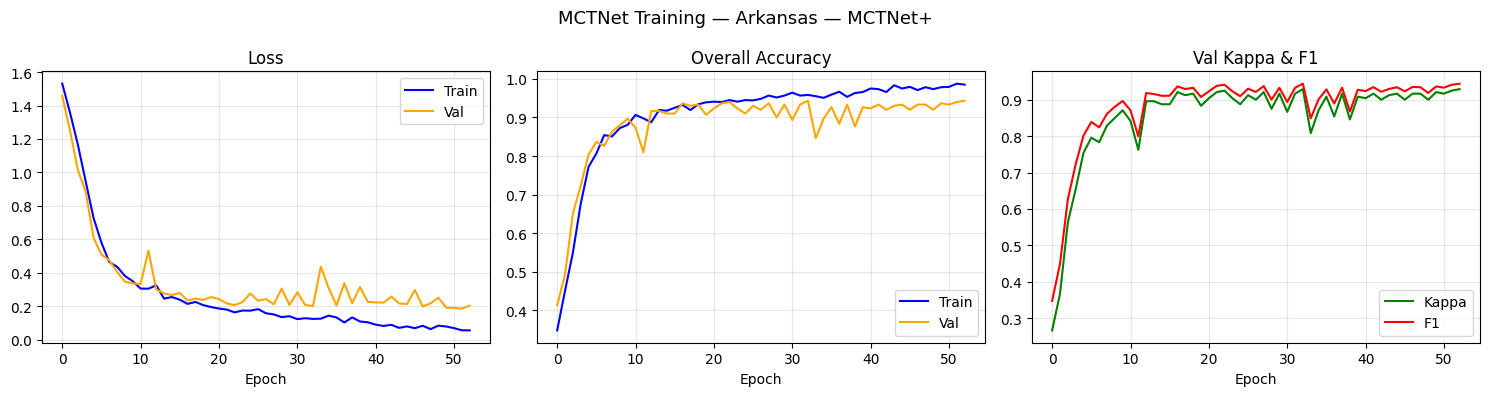

In [ ]:
model_ark_plus, history_ark_plus = train_model(
    model        = model_ark_plus,
    train_loader = ark_train,
    val_loader   = ark_val,
    n_epochs     = 200,
    lr           = 0.001,
    weight_decay = 1e-3,
    patience     = 20,
    device       = device,
    state_name   = f'Arkansas — MCTNet+ (S2 + {STUDY})'
)

_, oa, kappa, f1, preds_ark, labels_ark = evaluate(
    model_ark_plus, ark_test, nn.CrossEntropyLoss(), device
)
print(f"\nARKANSAS TEST RESULTS — MCTNet+")
print(f"  OA:    {oa:.4f}   (MCTNet Part1: 0.968)")
print(f"  Kappa: {kappa:.4f}   (MCTNet Part1: 0.951)")
print(f"  F1:    {f1:.4f}   (MCTNet Part1: 0.933)")
plot_history(history_ark_plus, 'Arkansas — MCTNet+')


Training MCTNet on California — MCTNet+ (S2 + soil)
  lr=0.001, weight_decay=0.005, patience=20
 Epoch | Train Loss |  Train OA |  Val Loss |  Val OA | Val Kappa |  Val F1
----------------------------------------------------------------------
     1 |     1.6837 |    0.2556 |    1.5666 |  0.3250 |    0.1900 |  0.2923 ← best
    10 |     0.6212 |    0.7646 |    0.6226 |  0.7889 |    0.7467 |  0.7836 ← best
    20 |     0.3904 |    0.8674 |    0.4536 |  0.8194 |    0.7833 |  0.8128
    30 |     0.3275 |    0.8792 |    0.4029 |  0.8500 |    0.8200 |  0.8477
    40 |     0.3071 |    0.8910 |    0.4453 |  0.8361 |    0.8033 |  0.8357
    50 |     0.2801 |    0.9028 |    0.4400 |  0.8583 |    0.8300 |  0.8564
    60 |     0.2414 |    0.9181 |    0.3833 |  0.8667 |    0.8400 |  0.8651
    70 |     0.1990 |    0.9271 |    0.3423 |  0.8833 |    0.8600 |  0.8827

⏹ Early stopping at epoch 75 (no improvement for 20 epochs)

✅ Best model at epoch 55 with Val Kappa = 0.8633

CALIFORNIA TEST RESULT

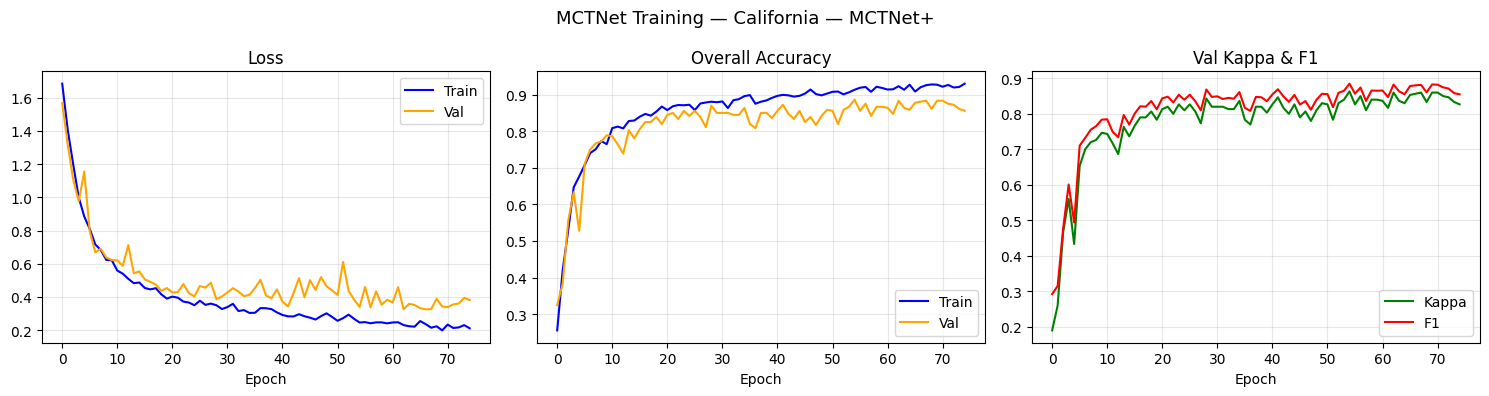

In [ ]:
model_cal_plus, history_cal_plus = train_model(
    model        = model_cal_plus,
    train_loader = cal_train,
    val_loader   = cal_val,
    n_epochs     = 200,
    lr           = 0.001,
    weight_decay = 5e-3,
    patience     = 20,
    device       = device,
    state_name   = f'California — MCTNet+ (S2 + {STUDY})'
)

_, oa, kappa, f1, preds_cal, labels_cal = evaluate(3  w
    model_cal_plus, cal_test, nn.CrossEntropyLoss(), device
)
print(f"\nCALIFORNIA TEST RESULTS — MCTNet+")
print(f"  OA:    {oa:.4f}   (MCTNet Part1: 0.852)")
print(f"  Kappa: {kappa:.4f}   (MCTNet Part1: 0.806)")
print(f"  F1:    {f1:.4f}   (MCTNet Part1: 0.829)")
plot_history(history_cal_plus, 'California — MCTNet+')

# **PART3**

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import os

class CropDatasetV2(Dataset):
    def __init__(self, X_s2, X_cov, mask, y, label_map):
        self.X_s2  = torch.tensor(X_s2,  dtype=torch.float32)
        self.X_cov = torch.tensor(X_cov, dtype=torch.float32) if X_cov is not None else None
        self.mask  = torch.tensor(mask,  dtype=torch.float32)
        self.y     = torch.tensor(
            [label_map[int(yi)] for yi in y], dtype=torch.long
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x_cov = self.X_cov[idx] if self.X_cov is not None else torch.zeros(1)
        return self.X_s2[idx], x_cov, self.mask[idx], self.y[idx]


def make_split_v2(X_s2, X_cov, mask, y, label_map,
                  n_train=240, n_val=60, seed=42, batch_size=64):
    rng = np.random.RandomState(seed)
    train_idx, val_idx, test_idx = [], [], []

    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        rng.shuffle(idx)
        train_idx.extend(idx[:n_train])
        val_idx.extend(idx[n_train:n_train + n_val])
        test_idx.extend(idx[n_train + n_val:])

    def make_ds(idxs):
        cov_sub = X_cov[idxs] if X_cov is not None else None
        return CropDatasetV2(X_s2[idxs], cov_sub, mask[idxs], y[idxs], label_map)

    return (
        DataLoader(make_ds(train_idx), batch_size=batch_size, shuffle=True,  num_workers=0),
        DataLoader(make_ds(val_idx),   batch_size=batch_size, shuffle=False, num_workers=0),
        DataLoader(make_ds(test_idx),  batch_size=batch_size, shuffle=False, num_workers=0),
    )

FEATURE_GROUPS = {
    None:      None,
    'climate': [5, 6, 7],
    'soil':    [2, 3, 4],
    'topo':    [0, 1],
    'all':     list(range(8)),
}

def make_loaders_v2(study, dataset_path,
                    X_ark, mask_ark, y_ark, ark_label_map,
                    X_cal, mask_cal, y_cal, cal_label_map,
                    batch_size=64):

    col_idx = FEATURE_GROUPS[study]

    if col_idx is None:
        X_cov_ark = np.zeros((len(X_ark), 36, 1), dtype=np.float32)
        X_cov_cal = np.zeros((len(X_cal), 36, 1), dtype=np.float32)
        n_cov_dim = 0   
    else:
        raw_ark = np.load(os.path.join(dataset_path, 'Arkansas_X_cov2.npy'))
        raw_cal = np.load(os.path.join(dataset_path, 'California_X_cov2.npy'))
        X_cov_ark = raw_ark[:, :, col_idx].astype(np.float32)
        X_cov_cal = raw_cal[:, :, col_idx].astype(np.float32)
        n_cov_dim = len(col_idx)

    print(f"\nConfig: S2 + {study}")
    print(f"  X_s2 shape   : {X_ark.shape}")
    print(f"  X_cov shape  : {X_cov_ark.shape}  (n_cov_dim={n_cov_dim})")

    ark_loaders = make_split_v2(
        X_ark, X_cov_ark, mask_ark, y_ark, ark_label_map, batch_size=batch_size
    )
    cal_loaders = make_split_v2(
        X_cal, X_cov_cal, mask_cal, y_cal, cal_label_map, batch_size=batch_size
    )
    return ark_loaders, cal_loaders, n_cov_dim


def build_model_v2(n_classes, n_cov_dim, device,
                   hidden_dim=64, n_stages=3, dropout=0.1):

    return MCTNetPlusPlus(
        n_bands    = 10,
        n_stages   = n_stages,
        hidden_dim = hidden_dim,
        kernel_size= 3,
        n_classes  = n_classes,
        n_cov_dim  = n_cov_dim,
        dropout    = dropout
    ).to(device)


print("Loaders V2 defined ✓")
print("CropDatasetV2 returns: (X_s2, X_cov, mask, y)")
print("make_loaders_v2  — covariates passed as separate branch, NOT fused into X_s2")

Loaders V2 defined ✓
CropDatasetV2 returns: (X_s2, X_cov, mask, y)
make_loaders_v2  — covariates passed as separate branch, NOT fused into X_s2


In [ ]:
import torch
import torch.nn as nn
import numpy as np


class ALPE(nn.Module):
    def __init__(self, d=64, T=36):
        super().__init__()
        pe  = torch.zeros(T, d)
        pos = torch.arange(T).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() * (-np.log(10000) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:pe[:, 1::2].shape[1]])
        self.register_buffer('pe', pe)
        self.conv = nn.Conv1d(d, d, kernel_size=3, padding=1)
        self.eca  = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(d, d, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x, mask=None):
        T_current = x.shape[1]
        pe = self.pe[:T_current].unsqueeze(0).expand(x.size(0), -1, -1)
        if mask is not None:
            pe = pe * (1 - mask.unsqueeze(-1))
        pe    = pe.transpose(1, 2)
        pe    = self.conv(pe)
        scale = self.eca(pe)
        return (pe * scale).transpose(1, 2)



class SpectralAttention(nn.Module):
    
    def __init__(self, n_bands):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(n_bands * 2, n_bands * 2),
            nn.ReLU(),
            nn.Linear(n_bands * 2, n_bands),
            nn.Sigmoid()
        )

    def forward(self, x):
        mu  = x.mean(dim=1)              
        std = x.std(dim=1).clamp(min=1e-6)  
        ctx = torch.cat([mu, std], dim=-1)  
        w   = self.attn(ctx).unsqueeze(1)   
        return x * w                         


class InputProjection(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU()
        )

    def forward(self, x):
        return self.proj(x)


class CNNBlock(nn.Module):
    def __init__(self, d, k=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(d, d, k, padding=k//2),
            nn.BatchNorm1d(d),
            nn.GELU(),
            nn.Conv1d(d, d, k, padding=k//2, dilation=1),
            nn.BatchNorm1d(d),
        )
        self.act = nn.GELU()

    def forward(self, x):
        # x: (B, T, d)
        xt  = x.transpose(1, 2)       # (B, d, T)
        out = self.net(xt)
        return self.act(out + xt).transpose(1, 2)


class AttentionGate(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(d * 2, d),
            nn.ReLU(),
            nn.Linear(d, d),
            nn.Sigmoid()
        )

    def forward(self, cnn_out, trans_out):
        combined = torch.cat([cnn_out, trans_out], dim=-1)
        g        = self.gate(combined)
        return g * cnn_out + (1 - g) * trans_out


class DualPool(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.max_pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.avg_pool = nn.AvgPool1d(kernel_size=2, stride=2)
        self.proj     = nn.Linear(d * 2, d)

    def forward(self, x):
        xt       = x.transpose(1, 2)
        max_out  = self.max_pool(xt).transpose(1, 2)
        avg_out  = self.avg_pool(xt).transpose(1, 2)
        combined = torch.cat([max_out, avg_out], dim=-1)
        return self.proj(combined)


class CTFusionPlusPlus(nn.Module):
    def __init__(self, d, n_head, k=3, dropout=0.1):
        super().__init__()
        self.alpe = ALPE(d=d, T=36)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d,
            nhead           = n_head,
            dim_feedforward = d * 4,
            batch_first     = True,
            dropout         = dropout,
            norm_first      = True,     # Pre-LN: more stable training
            activation      = 'gelu',
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.cnn  = CNNBlock(d, k)
        self.gate = AttentionGate(d)
        self.pool = DualPool(d)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        pos   = self.alpe(x, mask)
        xt    = x + pos
        t_out = self.transformer(xt)
        c_out = self.cnn(xt)
        fused = self.gate(self.drop(c_out), self.drop(t_out))
        return self.pool(fused)


class CovariateCrossAttention(nn.Module):
    def __init__(self, d, n_cov_dim, n_head=4, dropout=0.1):
        super().__init__()
        self.cov_proj = nn.Linear(n_cov_dim, d)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim   = d,
            num_heads   = n_head,
            dropout     = dropout,
            batch_first = True,
        )
        self.norm = nn.LayerNorm(d)
        self.drop = nn.Dropout(dropout)

    def forward(self, x_s2, x_cov):
        
        kv = self.cov_proj(x_cov)                      
        attn_out, _ = self.cross_attn(x_s2, kv, kv)   
        return self.norm(x_s2 + self.drop(attn_out))


class MCTNetPlusPlus(nn.Module):
    def __init__(self,
                 n_bands    = 10,
                 n_stages   = 3,
                 hidden_dim = 64,    
                 kernel_size= 3,
                 n_classes  = 5,
                 n_cov_dim  = 8,    
                 dropout    = 0.1):
        super().__init__()

        n_head = max(1, hidden_dim // 16)

        self.spectral_attn = SpectralAttention(n_bands)

        self.input_proj = InputProjection(n_bands, hidden_dim)

        self.stages = nn.ModuleList([
            CTFusionPlusPlus(d=hidden_dim, n_head=n_head,
                             k=kernel_size, dropout=dropout)
            for _ in range(n_stages)
        ])

        self.use_cov_ca = (n_cov_dim > 0)
        if self.use_cov_ca:
            self.cov_ca = CovariateCrossAttention(
                d=hidden_dim, n_cov_dim=n_cov_dim,
                n_head=n_head, dropout=dropout
            )

        self.global_max = nn.AdaptiveMaxPool1d(1)
        self.global_avg = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_classes)
        )

    def forward(self, x, mask=None, x_cov=None):
        
        x = self.spectral_attn(x)          
        x = self.input_proj(x)             

        m = mask
        for stage in self.stages:
            x = stage(x, m)               
            if m is not None and m.shape[1] > x.shape[1]:
                T_new = x.shape[1]
                m = m[:, :T_new * 2].reshape(m.shape[0], T_new, 2).max(-1).values

        if self.use_cov_ca and x_cov is not None:
            x = self.cov_ca(x, x_cov)     

        xt      = x.transpose(1, 2)                       
        max_out = self.global_max(xt).squeeze(-1)         
        avg_out = self.global_avg(xt).squeeze(-1)         
        pooled  = torch.cat([max_out, avg_out], dim=-1)  

        return self.classifier(pooled)                    


if __name__ == '__main__':
    print("=== MCTNet++ Architecture Test ===\n")

    model_pp = MCTNetPlusPlus(
        n_bands    = 10,
        n_stages   = 3,
        hidden_dim = 64,
        kernel_size= 3,
        n_classes  = 5,
        n_cov_dim  = 8,
        dropout    = 0.1
    )

    x_dummy    = torch.randn(32, 36, 10)
    mask_dummy = torch.zeros(32, 36)
    mask_dummy[:, [2, 5, 10]] = 1
    cov_dummy  = torch.randn(32, 36, 8)

    out = model_pp(x_dummy, mask_dummy, cov_dummy)
    print(f"Input S2 shape:  {x_dummy.shape}")
    print(f"Input cov shape: {cov_dummy.shape}")
    print(f"Output shape:    {out.shape}   ← should be (32, 5)")

    print(f"\nSequence length through stages:")
    print(f"  Input:   36  → proj → 36")
    print(f"  Stage 1: 18 (DualPool halves)")
    print(f"  Stage 2:  9")
    print(f"  Stage 3:  4")
    print(f"  Global pool: (max+avg) → 2×64 = 128 → classifier")

    n_pp   = sum(p.numel() for p in model_pp.parameters() if p.requires_grad)
    n_orig = 55059
    print(f"\nMCTNet   parameters: {n_orig:,}")
    print(f"MCTNet++ parameters: {n_pp:,}")
    print(f"MCTNet++ is {n_pp / n_orig * 100:.1f}% the size of MCTNet")
    print("\n✅ MCTNet++ working correctly — ready to train")

=== MCTNet++ Architecture Test ===

Input S2 shape:  torch.Size([32, 36, 10])
Input cov shape: torch.Size([32, 36, 8])
Output shape:    torch.Size([32, 5])   ← should be (32, 5)

Sequence length through stages:
  Input:   36  → proj → 36
  Stage 1: 18 (DualPool halves)
  Stage 2:  9
  Stage 3:  4
  Global pool: (max+avg) → 2×64 = 128 → classifier

MCTNet   parameters: 55,059
MCTNet++ parameters: 513,723
MCTNet++ is 933.0% the size of MCTNet

✅ MCTNet++ working correctly — ready to train


/tmp/ipykernel_8447/265522539.py:160: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)


In [ ]:

STUDY = 'soil'    # 'climate' | 'soil' | 'topo' | 'all' | None

ark_loaders, cal_loaders, n_cov_dim = make_loaders_v2clean(
    study        = STUDY,
    dataset_path = dataset_path,
    X_ark=X_ark, mask_ark=mask_ark, y_ark=y_ark, ark_label_map=ark_label_map,
    X_cal=X_cal, mask_cal=mask_cal, y_cal=y_cal, cal_label_map=cal_label_map,
    batch_size   = 64,
)
ark_train, ark_val, ark_test = ark_loaders
cal_train, cal_val, cal_test = cal_loaders

model_ark_pp = build_model_v2(n_classes=5, n_cov_dim=n_cov_dim, device='cpu',
                               hidden_dim=64, n_stages=3, dropout=0.2)
model_cal_pp = build_model_v2(n_classes=6, n_cov_dim=n_cov_dim, device='cpu',
                               hidden_dim=64, n_stages=3, dropout=0.1)

n_pp = sum(p.numel() for p in model_ark_pp.parameters() if p.requires_grad)
print(f"\nMCTNet++ parameters: {n_pp:,}")
print(f"Study:               S2 + {STUDY}")
print(f"n_cov_dim:           {n_cov_dim}")

Study: S2 + soil  |  n_cov_dim=3

MCTNet++ parameters: 513,403
Study:               S2 + soil
n_cov_dim:           3


/tmp/ipykernel_8447/265522539.py:160: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)


In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import cohen_kappa_score, f1_score
import numpy as np
import matplotlib.pyplot as plt


def train_one_epoch_v2(model, loader, optimizer, criterion, device, clip_grad=1.0):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_s2, X_cov, mask, y in loader:
        X_s2 = X_s2.to(device)
        X_cov = X_cov.to(device)
        mask = mask.to(device)
        y    = y.to(device)

        optimizer.zero_grad()
        outputs = model(X_s2, mask, x_cov=X_cov)
        loss    = criterion(outputs, y)
        loss.backward()
        if clip_grad > 0:
            nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        optimizer.step()

        total_loss += loss.item() * len(y)
        correct    += outputs.argmax(dim=1).eq(y).sum().item()
        total      += len(y)
    return total_loss / total, correct / total


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def evaluate_v2(model, loader, criterion, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_s2, X_cov, mask, y in loader:
            X_s2  = X_s2.to(device)
            X_cov = X_cov.to(device)
            mask  = mask.to(device)
            y     = y.to(device)

            outputs = model(X_s2, mask, x_cov=X_cov)
            loss    = criterion(outputs, y)
            total_loss += loss.item() * len(y)
            preds       = outputs.argmax(dim=1)
            correct    += preds.eq(y).sum().item()
            total      += len(y)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    oa    = correct / total
    kappa = cohen_kappa_score(all_labels, all_preds)
    f1    = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / total, oa, kappa, f1, all_preds, all_labels

def train_model_v2(model, train_loader, val_loader,
                   n_epochs=250, lr=5e-4,
                   weight_decay=1e-2,
                   patience=25,
                   label_smoothing=0.05,
                   device='cuda',
                   state_name=''):
    
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=lr * 0.05)

    best_val_kappa    = 0.0
    best_epoch        = 0
    best_weights      = None
    epochs_no_improve = 0

    history = {
        'train_loss': [], 'val_loss':  [],
        'train_oa':   [], 'val_oa':    [],
        'val_kappa':  [], 'val_f1':    [],
        'lr':         []
    }

    print(f"\n{'='*75}")
    print(f"Training MCTNet++ on {state_name}")
    print(f"  lr={lr}, wd={weight_decay}, patience={patience}, "
          f"label_smooth={label_smoothing}")
    print(f"{'='*75}")
    print(f"{'Epoch':>6} | {'Tr Loss':>8} | {'Tr OA':>7} | "
          f"{'Va Loss':>8} | {'Va OA':>7} | {'Kappa':>7} | {'F1':>7} | {'LR':>8}")
    print(f"{'-'*75}")

    for epoch in range(1, n_epochs + 1):
        train_loss, train_oa = train_one_epoch_v2(
            model, train_loader, optimizer, criterion, device)
        val_loss, val_oa, val_kappa, val_f1, _, _ = evaluate_v2(
            model, val_loader, criterion, device)

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_oa'].append(train_oa)
        history['val_oa'].append(val_oa)
        history['val_kappa'].append(val_kappa)
        history['val_f1'].append(val_f1)
        history['lr'].append(current_lr)

        if val_kappa > best_val_kappa:
            best_val_kappa    = val_kappa
            best_epoch        = epoch
            best_weights      = {k: v.cpu().clone()
                                 for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epoch % 10 == 0 or epoch == 1:
            marker = ' ←' if epoch == best_epoch else ''
            print(f"{epoch:>6} | {train_loss:>8.4f} | {train_oa:>7.4f} | "
                  f"{val_loss:>8.4f} | {val_oa:>7.4f} | "
                  f"{val_kappa:>7.4f} | {val_f1:>7.4f} | "
                  f"{current_lr:>8.2e}{marker}")

        if epochs_no_improve >= patience:
            print(f"\n⏹  Early stopping at epoch {epoch} "
                  f"(no improvement for {patience} epochs)")
            break

    print(f"\n✅ Best model at epoch {best_epoch} "
          f"with Val Kappa = {best_val_kappa:.4f}")
    model.load_state_dict({k: v.to(device)
                           for k, v in best_weights.items()})
    return model, history


def plot_history_v2(history, state_name):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    axes[0].plot(history['train_loss'], label='Train', color='steelblue')
    axes[0].plot(history['val_loss'],   label='Val',   color='tomato')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history['train_oa'], label='Train', color='steelblue')
    axes[1].plot(history['val_oa'],   label='Val',   color='tomato')
    axes[1].set_title('Overall Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(history['val_kappa'], label='Kappa', color='seagreen')
    axes[2].plot(history['val_f1'],    label='F1',    color='darkorange')
    axes[2].set_title('Val Kappa & F1')
    axes[2].set_xlabel('Epoch')
    axes[2].legend(); axes[2].grid(alpha=0.3)

    axes[3].plot(history['lr'], color='purple')
    axes[3].set_title('Learning Rate (Cosine)')
    axes[3].set_xlabel('Epoch')
    axes[3].grid(alpha=0.3)

    plt.suptitle(f'MCTNet++ Training — {state_name}', fontsize=13)
    plt.tight_layout()
    plt.show()


print("Training utilities V2 defined ✓")
print("  train_model_v2  — AdamW + CosineAnnealingLR + label smoothing")
print("  evaluate_v2     — passes x_cov to model")

Training utilities V2 defined ✓
  train_model_v2  — AdamW + CosineAnnealingLR + label smoothing
  evaluate_v2     — passes x_cov to model


NEW VARIANT



Training MCTNet++ on California — MCTNet++ (S2 + soil)
  lr=0.0003, wd=0.01, patience=50, label_smooth=0.05
 Epoch |  Tr Loss |   Tr OA |  Va Loss |   Va OA |   Kappa |      F1 |       LR
---------------------------------------------------------------------------
     1 |   1.5770 |  0.4028 |   1.6112 |  0.3083 |  0.1700 |  0.2371 | 3.00e-04 ←
    10 |   0.6289 |  0.8507 |   0.6147 |  0.8361 |  0.8033 |  0.8340 | 3.00e-04
    20 |   0.5202 |  0.8924 |   0.5317 |  0.8750 |  0.8500 |  0.8763 | 2.98e-04 ←
    30 |   0.4406 |  0.9111 |   0.5376 |  0.8944 |  0.8733 |  0.8928 | 2.96e-04
    40 |   0.4009 |  0.9340 |   0.5140 |  0.8889 |  0.8667 |  0.8878 | 2.93e-04
    50 |   0.3792 |  0.9493 |   0.5542 |  0.8778 |  0.8533 |  0.8774 | 2.89e-04
    60 |   0.3521 |  0.9576 |   0.4968 |  0.9083 |  0.8900 |  0.9086 | 2.84e-04
    70 |   0.3502 |  0.9590 |   0.4916 |  0.9000 |  0.8800 |  0.9008 | 2.79e-04
    80 |   0.3018 |  0.9806 |   0.5084 |  0.9028 |  0.8833 |  0.9022 | 2.73e-04
    90 |   

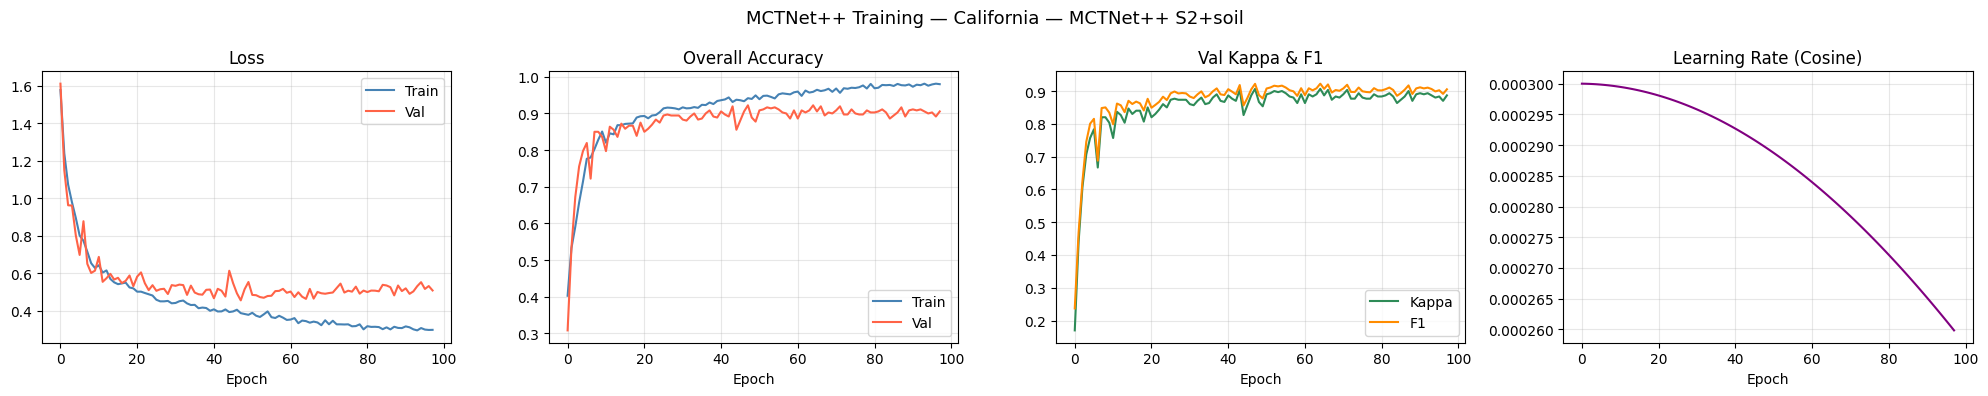

In [ ]:
model_cal_pp, history_cal_pp = train_model_v2(
    model           = model_cal_pp,
    train_loader    = cal_train,
    val_loader      = cal_val,
    n_epochs        = 400,
    lr              = 4e-4,
    weight_decay    = 2e-2,
    patience        = 50,
    label_smoothing = 0.05,
    device          = 'cpu',
    state_name      = f'California — MCTNet++ (S2 + {STUDY})'
)

_, oa_c, kappa_c, f1_c, preds_cal, labels_cal = evaluate_v2(
    model_cal_pp, cal_test, nn.CrossEntropyLoss()
)
print(f"\nCALIFORNIA TEST — MCTNet++")
print(f"  OA:    {oa_c:.4f}  ")
print(f"  Kappa: {kappa_c:.4f}  ")
print(f"  F1:    {f1_c:.4f}  ")
plot_history_v2(history_cal_pp, f'California — MCTNet++ S2+{STUDY}')


Training MCTNet++ on Arkansas — MCTNet++ (S2 + soil)
  lr=0.0005, wd=0.01, patience=60, label_smooth=0.05
 Epoch |  Tr Loss |   Tr OA |  Va Loss |   Va OA |   Kappa |      F1 |       LR
---------------------------------------------------------------------------
     1 |   1.5593 |  0.2767 |   1.5645 |  0.3133 |  0.1417 |  0.1797 | 5.00e-04 ←
    10 |   0.5478 |  0.8642 |   0.4991 |  0.8900 |  0.8625 |  0.8920 | 5.00e-04 ←
    20 |   0.4150 |  0.9175 |   0.4966 |  0.9067 |  0.8833 |  0.9071 | 4.98e-04
    30 |   0.3598 |  0.9500 |   0.3818 |  0.9467 |  0.9333 |  0.9467 | 4.96e-04
    40 |   0.3388 |  0.9525 |   0.3971 |  0.9333 |  0.9167 |  0.9338 | 4.93e-04
    50 |   0.3207 |  0.9625 |   0.3769 |  0.9400 |  0.9250 |  0.9392 | 4.88e-04
    60 |   0.3072 |  0.9667 |   0.3244 |  0.9633 |  0.9542 |  0.9631 | 4.83e-04
    70 |   0.2884 |  0.9767 |   0.3301 |  0.9667 |  0.9583 |  0.9668 | 4.77e-04
    80 |   0.2780 |  0.9833 |   0.3531 |  0.9600 |  0.9500 |  0.9595 | 4.71e-04
    90 |   0.

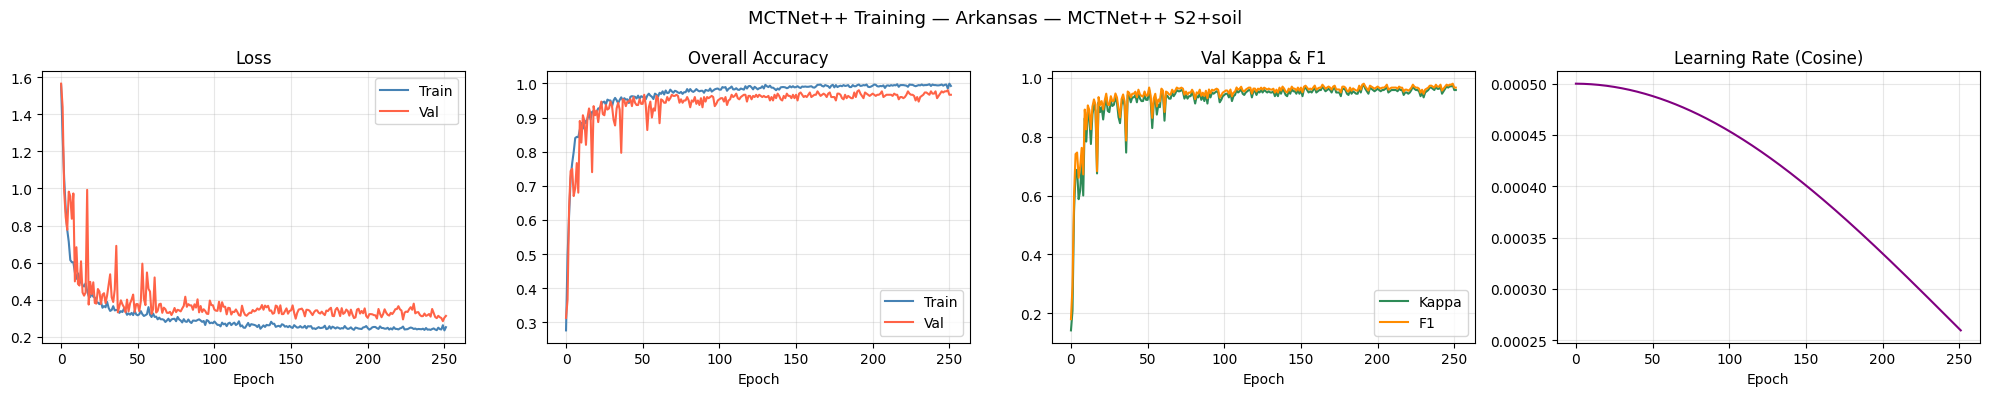

In [ ]:
model_ark_pp, history_ark_pp = train_model_v2(
    model           = model_ark_pp,
    train_loader    = ark_train,
    val_loader      = ark_val,
    n_epochs        = 500,
    lr              = 5e-4,
    weight_decay    = 1e-2,
    patience        = 60,
    label_smoothing = 0.05,
    device          = 'cpu',
    state_name      = f'Arkansas — MCTNet++ (S2 + {STUDY})'
)

_, oa, kappa, f1, preds_ark, labels_ark = evaluate_v2(
    model_ark_pp, ark_test, nn.CrossEntropyLoss()
)
print(f"\nARKANSAS TEST — MCTNet++")
print(f"  OA:    {oa:.4f}  ")
print(f"  Kappa: {kappa:.4f} ")
print(f"  F1:    {f1:.4f}   ")
plot_history_v2(history_ark_pp, f'Arkansas — MCTNet++ S2+{STUDY}')

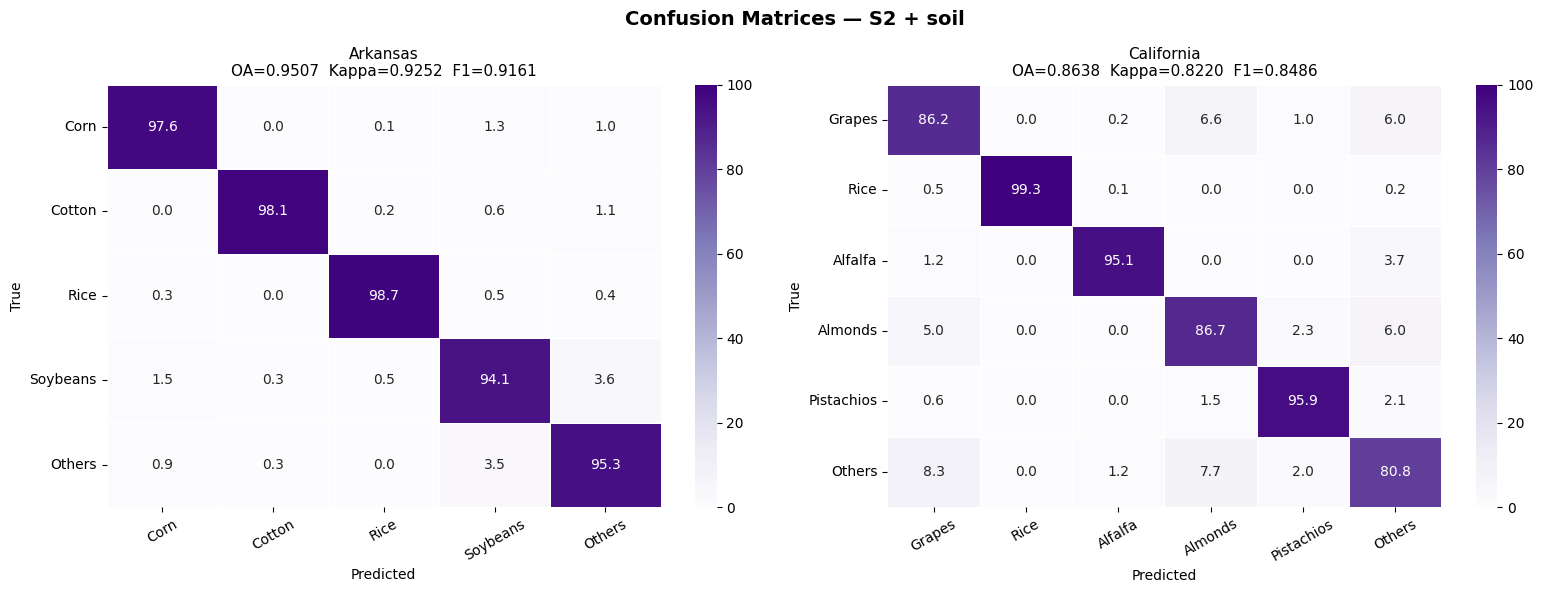


CLASSIFICATION REPORT — Arkansas (S2 + soil)
              precision    recall  f1-score   support

        Corn     0.9416    0.9763    0.9586      1222
      Cotton     0.9638    0.9805    0.9721       462
        Rice     0.9891    0.9873    0.9882      2123
    Soybeans     0.9904    0.9408    0.9650      4377
      Others     0.6193    0.9525    0.7506       316

    accuracy                         0.9601      8500
   macro avg     0.9009    0.9675    0.9269      8500
weighted avg     0.9678    0.9601    0.9623      8500


CLASSIFICATION REPORT — California (S2 + soil)
              precision    recall  f1-score   support

      Grapes     0.8299    0.8620    0.8456      1754
        Rice     1.0000    0.9931    0.9965      1737
     Alfalfa     0.9371    0.9510    0.9440       674
     Almonds     0.5331    0.8675    0.6604       483
  Pistachios     0.7780    0.9588    0.8590       340
      Others     0.9389    0.8079    0.8685      3212

    accuracy                         

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def plot_confusion_matrices(preds_ark, labels_ark,
                             preds_cal, labels_cal,
                             study_name):
    cm_ark = confusion_matrix(labels_ark, preds_ark)
    cm_cal = confusion_matrix(labels_cal, preds_cal)
    cm_ark_pct = cm_ark.astype(float) / cm_ark.sum(axis=1, keepdims=True) * 100
    cm_cal_pct = cm_cal.astype(float) / cm_cal.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Confusion Matrices — S2 + {study_name}',
                 fontsize=14, fontweight='bold')

    sns.heatmap(cm_ark_pct, ax=axes[0],
                annot=True, fmt='.1f', cmap='Purples',
                xticklabels=ark_class_names, yticklabels=ark_class_names,
                vmin=0, vmax=100, linewidths=0.5, linecolor='white')
    axes[0].set_title('Arkansas\nOA=0.9507  Kappa=0.9252  F1=0.9161', fontsize=11)  # ← hardcoded
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].tick_params(axis='y', rotation=0)

    sns.heatmap(cm_cal_pct, ax=axes[1],
                annot=True, fmt='.1f', cmap='Purples',
                xticklabels=cal_class_names, yticklabels=cal_class_names,
                vmin=0, vmax=100, linewidths=0.5, linecolor='white')
    axes[1].set_title('California\nOA=0.8638  Kappa=0.8220  F1=0.8486', fontsize=11)  # ← hardcoded
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*60}")
    print(f"CLASSIFICATION REPORT — Arkansas (S2 + {study_name})")
    print(f"{'='*60}")
    print(classification_report(labels_ark, preds_ark, target_names=ark_class_names, digits=4, zero_division=0))

    print(f"\n{'='*60}")
    print(f"CLASSIFICATION REPORT — California (S2 + {study_name})")
    print(f"{'='*60}")
    print(classification_report(labels_cal, preds_cal, target_names=cal_class_names, digits=4, zero_division=0))

plot_confusion_matrices(preds_ark, labels_ark, preds_cal, labels_cal, study_name=str(STUDY))